In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_mumbai = pd.read_csv("../data/raw/zomato_res_final_f.csv",encoding="latin-1")

In [4]:
df_mumbai.head()

,Additional_outlet_count,Call,Cost_for_two,Cuisines,Features,Home_Delivery,Operational_hours,Restaurant_Location,Restaurant_Name,Restaurant_Type,...,Delivery_Time(mins),Rating,Votes,Rating_Category,Operational_after_Midnight,Cuisine_count,Feature_Count,Res_Type_Count,Competitors_in_Location,Score
0,2.0,True,250,Bakery,Food Hygiene Rated Restaurants In Mumbai,True,10am â 11pm (Mon-Sun),Airoli,Bake Ur Day,Bakery,...,60.0,4.0,308.0,Very Good,False,1,1,1,68.0,29.435336
1,9.0,True,300,"Bakery, Desserts",NaN,False,9am â 10pm (Mon-Sun),Airoli,Cake Street,Bakery,...,NaN,3.7,64.0,Good,False,2,1,1,68.0,23.822936
2,NaN,True,300,Bakery,NaN,True,10am â 11pm (Mon-Sun),Airoli,Tiers Of Joy,Bakery,...,136.0,4.0,156.0,Very Good,False,1,1,1,68.0,28.516814
3,NaN,True,500,"Cafe, Desserts",NaN,False,9am â 11pm (Mon-Sun),Airoli,FNP Cakes N More,Bakery,...,NaN,3.3,8.0,Average,False,2,1,2,68.0,17.967292
4,NaN,True,300,"Bakery, Desserts",Food Hygiene Rated Restaurants In Mumbai,True,9:30am â 12midnight (Mon-Sun),Airoli,Cake Boutique,Bakery,...,115.0,3.9,309.0,Good,False,2,1,2,68.0,28.062068


In [5]:
df_mumbai.shape

(5956, 22)

In [6]:
df_mumbai.columns.tolist()

['Additional_outlet_count',
 'Call',
 'Cost_for_two',
 'Cuisines',
 'Features',
 'Home_Delivery',
 'Operational_hours',
 'Restaurant_Location',
 'Restaurant_Name',
 'Restaurant_Type',
 'View_Menu',
 'Min_Order(Rs.)',
 'Delivery_Time(mins)',
 'Rating',
 'Votes',
 'Rating_Category',
 'Operational_after_Midnight',
 'Cuisine_count',
 'Feature_Count',
 'Res_Type_Count',
 'Competitors_in_Location',
 'Score']

In [7]:
df_mumbai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5956 entries, 0 to 5955
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Additional_outlet_count     833 non-null    float64
 1   Call                        5956 non-null   bool   
 2   Cost_for_two                5956 non-null   int64  
 3   Cuisines                    5956 non-null   object 
 4   Features                    1232 non-null   object 
 5   Home_Delivery               5956 non-null   bool   
 6   Operational_hours           5950 non-null   object 
 7   Restaurant_Location         5956 non-null   object 
 8   Restaurant_Name             5956 non-null   object 
 9   Restaurant_Type             5956 non-null   object 
 10  View_Menu                   5956 non-null   bool   
 11  Min_Order(Rs.)              2100 non-null   float64
 12  Delivery_Time(mins)         2100 non-null   float64
 13  Rating                      5956 

In [8]:
df_mumbai.head()

,Additional_outlet_count,Call,Cost_for_two,Cuisines,Features,Home_Delivery,Operational_hours,Restaurant_Location,Restaurant_Name,Restaurant_Type,...,Delivery_Time(mins),Rating,Votes,Rating_Category,Operational_after_Midnight,Cuisine_count,Feature_Count,Res_Type_Count,Competitors_in_Location,Score
0,2.0,True,250,Bakery,Food Hygiene Rated Restaurants In Mumbai,True,10am â 11pm (Mon-Sun),Airoli,Bake Ur Day,Bakery,...,60.0,4.0,308.0,Very Good,False,1,1,1,68.0,29.435336
1,9.0,True,300,"Bakery, Desserts",NaN,False,9am â 10pm (Mon-Sun),Airoli,Cake Street,Bakery,...,NaN,3.7,64.0,Good,False,2,1,1,68.0,23.822936
2,NaN,True,300,Bakery,NaN,True,10am â 11pm (Mon-Sun),Airoli,Tiers Of Joy,Bakery,...,136.0,4.0,156.0,Very Good,False,1,1,1,68.0,28.516814
3,NaN,True,500,"Cafe, Desserts",NaN,False,9am â 11pm (Mon-Sun),Airoli,FNP Cakes N More,Bakery,...,NaN,3.3,8.0,Average,False,2,1,2,68.0,17.967292
4,NaN,True,300,"Bakery, Desserts",Food Hygiene Rated Restaurants In Mumbai,True,9:30am â 12midnight (Mon-Sun),Airoli,Cake Boutique,Bakery,...,115.0,3.9,309.0,Good,False,2,1,2,68.0,28.062068


In [9]:
missing = pd.DataFrame({
    "Missing Values": df_mumbai.isnull().sum(),
    "Missing %": (df_mumbai.isnull().sum() / len(df_mumbai) * 100).round(2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Values,Missing %
Additional_outlet_count,5123,86.01
Features,4724,79.31
Delivery_Time(mins),3856,64.74
Min_Order(Rs.),3856,64.74
Operational_hours,6,0.10
Cuisines,0,0.00
Votes,0,0.00
Competitors_in_Location,0,0.00
Res_Type_Count,0,0.00
Feature_Count,0,0.00


In [10]:
print("Duplicate rows:", df_mumbai.duplicated().sum())

Duplicate rows: 32


In [11]:
df_mumbai["Restaurant_Location"].nunique()

120

In [12]:
df_mumbai["Restaurant_Location"].value_counts().head(30)

Restaurant_Location
Thane West         360
Andheri West       245
Bandra West        204
Mira Road          198
Malad West         190
Borivali West      188
Chembur            136
Kalyan             124
Kandivali West     121
Dombivali East     120
Kharghar           119
Powai              113
Vasai              110
Vashi              109
Lower Parel        107
Mulund West        104
Juhu                94
Fort                93
Goregaon East       88
Vile Parle East     85
Chakala             81
Kandivali East      80
Colaba              78
Khar                75
Goregaon West       71
Nerul               69
Marol               68
Mahakali            67
Ghatkopar East      64
Santacruz East      61
Name: count, dtype: int64

In [13]:
keywords = ["Mumbai", "Navi Mumbai", "Thane", "Airoli"]

for keyword in keywords:
    mask = df_mumbai["Restaurant_Location"].astype(str).str.contains(
        keyword,
        case=False,
        na=False
    )
    
    print(f"{keyword}: {mask.sum()} restaurants")

Mumbai: 48 restaurants
Navi Mumbai: 0 restaurants
Thane: 371 restaurants
Airoli: 61 restaurants


In [14]:
df_mumbai[
    df_mumbai["Restaurant_Location"]
    .astype(str)
    .str.contains("Navi Mumbai", case=False, na=False)
]["Restaurant_Location"].value_counts()

Series([], Name: count, dtype: int64)

In [15]:
df_mumbai[
    df_mumbai["Restaurant_Location"]
    .astype(str)
    .str.contains("Thane", case=False, na=False)
]["Restaurant_Location"].value_counts()

Restaurant_Location
Thane West    360
Thane East     11
Name: count, dtype: int64

In [16]:
for col in [
    "Cuisines",
    "Rating",
    "Votes",
    "Cost_for_two",
    "Restaurant_Type"
]:
    if col in df_mumbai.columns:
        print(f"\n--- {col} ---")
        print(df_mumbai[col].head())


--- Cuisines ---
0              Bakery
1    Bakery, Desserts
2              Bakery
3      Cafe, Desserts
4    Bakery, Desserts
Name: Cuisines, dtype: object

--- Rating ---
0    4.0
1    3.7
2    4.0
3    3.3
4    3.9
Name: Rating, dtype: float64

--- Votes ---
0    308.0
1     64.0
2    156.0
3      8.0
4    309.0
Name: Votes, dtype: float64

--- Cost_for_two ---
0    250
1    300
2    300
3    500
4    300
Name: Cost_for_two, dtype: int64

--- Restaurant_Type ---
0    Bakery
1    Bakery
2    Bakery
3    Bakery
4    Bakery
Name: Restaurant_Type, dtype: object


In [17]:
df_mumbai.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Additional_outlet_count,833.0,NaN,NaN,NaN,4.669868,14.273269,1.0,1.0,1.0,3.0,262.0
Call,5956,1,True,5956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cost_for_two,5956.0,NaN,NaN,NaN,667.374412,742.600576,50.0,350.0,500.0,700.0,30000.0
Cuisines,5956,2071,"North Indian, Chinese",258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Features,1232,362,Food Hygiene Rated Restaurants In Mumbai,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Home_Delivery,5956,2,False,3856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operational_hours,5950,1524,11am â 11pm (Mon-Sun),322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurant_Location,5956,120,Thane West,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurant_Name,5956,5637,Trupti,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Restaurant_Type,5956,7,Casual Dining,2940,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
duplicates = df_mumbai[df_mumbai.duplicated(keep=False)]

duplicates.sort_values(
    ["Restaurant_Location", "Restaurant_Name"]
).head(20)

,Additional_outlet_count,Call,Cost_for_two,Cuisines,Features,Home_Delivery,Operational_hours,Restaurant_Location,Restaurant_Name,Restaurant_Type,...,Delivery_Time(mins),Rating,Votes,Rating_Category,Operational_after_Midnight,Cuisine_count,Feature_Count,Res_Type_Count,Competitors_in_Location,Score
4331,NaN,True,500,"North Indian, Chinese",20% off on all orders,True,"Closed (Mon),12noon â 3am (Tue-Sun)",Andheri West,Cinnamon N Nutmeg,Food Court,...,30.0,4.1,153.0,Very Good,True,2,1,1,295.0,29.877996
4333,NaN,True,500,"North Indian, Chinese",20% off on all orders,True,"Closed (Mon),12noon â 3am (Tue-Sun)",Andheri West,Cinnamon N Nutmeg,Food Court,...,30.0,4.1,153.0,Very Good,True,2,1,1,295.0,29.877996
4328,NaN,True,400,North Indian,Food Hygiene Rated Restaurants In Mumbai,True,"12noon â 4pm, 7pm â 3:30am (Mon-Sun)",Andheri West,Dilli Deli,Food Court,...,45.0,3.7,411.0,Good,True,1,1,1,295.0,25.919824
4329,NaN,True,400,North Indian,Food Hygiene Rated Restaurants In Mumbai,True,"12noon â 4pm, 7pm â 3:30am (Mon-Sun)",Andheri West,Dilli Deli,Food Court,...,45.0,3.7,411.0,Good,True,1,1,1,295.0,25.919824
278,NaN,True,1000,"Continental, Italian, Pizza, North Indian, Chi...",50% off on all orders above â¹500,True,"12midnight â 1:30am, 12noon â 12midnight (...",Andheri West,The Liquor Factory,Bar,...,45.0,3.9,818.0,Good,False,8,1,2,295.0,31.137907
279,NaN,True,1000,"Continental, Italian, Pizza, North Indian, Chi...",50% off on all orders above â¹500,True,"12midnight â 1:30am, 12noon â 12midnight (...",Andheri West,The Liquor Factory,Bar,...,45.0,3.9,818.0,Good,False,8,1,2,295.0,31.137907
575,NaN,True,300,"Continental, Fast Food, Beverages, Italian, Pizza",Food Hygiene Rated Restaurants In Mumbai,True,12noon â 12midnight (Mon-Sun),Borivali West,Dosti Yaari,CafÃ©,...,45.0,3.8,135.0,Good,False,5,1,1,193.0,25.631293
576,NaN,True,300,"Continental, Fast Food, Beverages, Italian, Pizza",Food Hygiene Rated Restaurants In Mumbai,True,12noon â 12midnight (Mon-Sun),Borivali West,Dosti Yaari,CafÃ©,...,45.0,3.8,135.0,Good,False,5,1,1,193.0,25.631293
1305,NaN,True,900,"Biryani, Beverages, Desserts, North Indian, Ch...",Food Hygiene Rated Restaurants In Mumbai,True,11:30am â 12:30AM (Mon-Sun),CBD-Belapur,Pranaam Fine Dine & Bar,Casual Dining,...,40.0,3.8,262.0,Good,True,5,1,2,58.0,26.398741
1306,NaN,True,900,"Biryani, Beverages, Desserts, North Indian, Ch...",Food Hygiene Rated Restaurants In Mumbai,True,11:30am â 12:30AM (Mon-Sun),CBD-Belapur,Pranaam Fine Dine & Bar,Casual Dining,...,40.0,3.8,262.0,Good,True,5,1,2,58.0,26.398741


In [19]:
df_mumbai[
    [
        "Restaurant_Name",
        "Restaurant_Location",
        "Restaurant_Type",
        "Cuisines",
        "Cost_for_two",
        "Rating",
        "Votes",
        "Home_Delivery",
        "Min_Order(Rs.)",
        "Delivery_Time(mins)"
    ]
].head(10)

,Restaurant_Name,Restaurant_Location,Restaurant_Type,Cuisines,Cost_for_two,Rating,Votes,Home_Delivery,Min_Order(Rs.),Delivery_Time(mins)
0,Bake Ur Day,Airoli,Bakery,Bakery,250,4.0,308.0,True,0.0,60.0
1,Cake Street,Airoli,Bakery,"Bakery, Desserts",300,3.7,64.0,False,NaN,NaN
2,Tiers Of Joy,Airoli,Bakery,Bakery,300,4.0,156.0,True,0.0,136.0
3,FNP Cakes N More,Airoli,Bakery,"Cafe, Desserts",500,3.3,8.0,False,NaN,NaN
4,Cake Boutique,Airoli,Bakery,"Bakery, Desserts",300,3.9,309.0,True,99.0,115.0
5,Top In Town Bakery,Ambernath,Bakery,"Bakery, Fast Food",400,3.3,10.0,False,NaN,NaN
6,Cakers & Cakers,Andheri West,Bakery,Bakery,300,4.2,233.0,True,99.0,60.0
7,Cookie me up,Andheri West,Bakery,Bakery,300,3.6,25.0,False,NaN,NaN
8,New Super Sweets,Andheri West,Bakery,"Bakery, Desserts",200,3.8,78.0,True,0.0,45.0
9,Cake Tree,Andheri West,Bakery,"Bakery, Desserts",350,3.2,64.0,True,99.0,45.0


In [20]:
# Check duplicate rows
print("Duplicate rows:", df_mumbai.duplicated().sum())

# Remove exact duplicates
df_clean = df_mumbai.drop_duplicates().copy()

print("Original shape:", df_mumbai.shape)
print("Cleaned shape:", df_clean.shape)

Duplicate rows: 32
Original shape: (5956, 22)
Cleaned shape: (5924, 22)


In [21]:
df_clean = df_clean.drop(
    columns=["Additional_outlet_count", "Features"]
)

print(df_clean.shape)

(5924, 20)


In [22]:
missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing %": (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing = missing[missing["Missing Values"] > 0] \
    .sort_values("Missing %", ascending=False)

missing

,Missing Values,Missing %
Min_Order(Rs.),3836,64.75
Delivery_Time(mins),3836,64.75
Operational_hours,6,0.10


In [23]:
df_clean[
    ["Home_Delivery", "Min_Order(Rs.)", "Delivery_Time(mins)"]
].isnull().sum()

Home_Delivery             0
Min_Order(Rs.)         3836
Delivery_Time(mins)    3836
dtype: int64

In [24]:
pd.crosstab(
    df_clean["Home_Delivery"],
    df_clean["Delivery_Time(mins)"].isnull()
)

Delivery_Time(mins),False,True
Home_Delivery,,
False,0,3836
True,2088,0


In [25]:
pd.crosstab(
    df_clean["Home_Delivery"],
    [
        df_clean["Min_Order(Rs.)"].isnull(),
        df_clean["Delivery_Time(mins)"].isnull()
    ]
)

Min_Order(Rs.),False,True
Delivery_Time(mins),False,True
Home_Delivery,,
False,0,3836
True,2088,0


In [26]:
df_clean.groupby("Home_Delivery")[[
    "Min_Order(Rs.)",
    "Delivery_Time(mins)"
]].agg(["count", "mean", "median", "min", "max"])

Min_Order(Rs.)                              Delivery_Time(mins)  \
                       count      mean median  min    max               count   
Home_Delivery                                                                   
False                      0       NaN    NaN  NaN    NaN                   0   
True                    2088  79.96887   99.0  0.0  500.0                2088   

                                               
                    mean median   min     max  
Home_Delivery                                  
False                NaN    NaN   NaN     NaN  
True           45.795498   45.0  20.0  1440.0

In [27]:
# Missing delivery-related values are structurally missing
# because these restaurants do not offer home delivery.

df_clean[["Home_Delivery", "Min_Order(Rs.)", "Delivery_Time(mins)"]].isnull().sum()

Home_Delivery             0
Min_Order(Rs.)         3836
Delivery_Time(mins)    3836
dtype: int64

In [28]:
df_clean["Min_Order_Applicable"] = df_clean["Home_Delivery"]
df_clean["Delivery_Time_Applicable"] = df_clean["Home_Delivery"]

In [29]:
location_summary = (
    df_clean["Restaurant_Location"]
    .value_counts()
    .reset_index()
)

location_summary.columns = ["Restaurant_Location", "Restaurant_Count"]

location_summary.head(20)

,Restaurant_Location,Restaurant_Count
0,Thane West,360
1,Andheri West,242
2,Bandra West,204
3,Mira Road,196
4,Malad West,189
5,Borivali West,187
6,Chembur,136
7,Kalyan,123
8,Dombivali East,120
9,Kandivali West,120


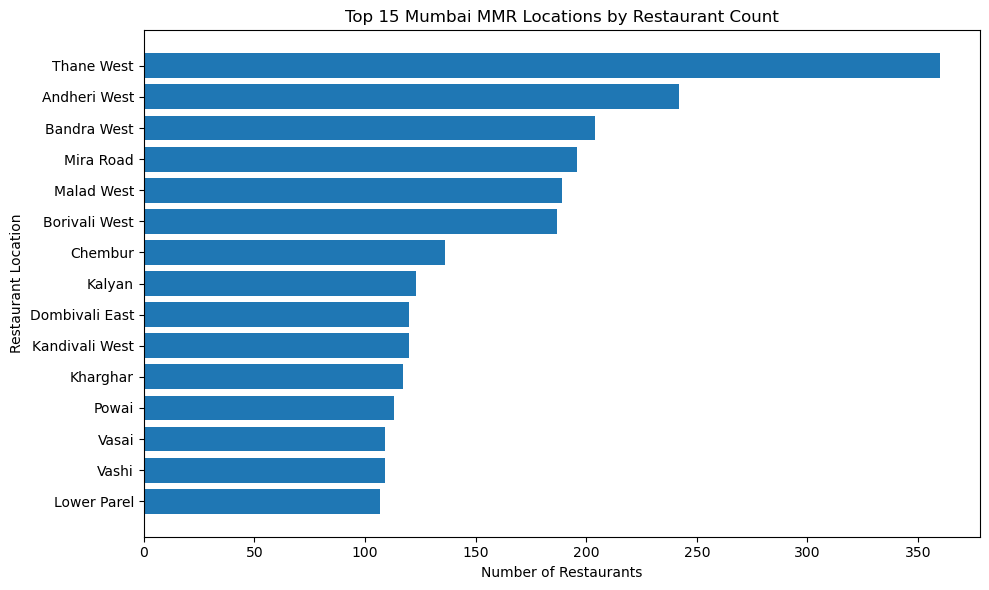

In [30]:
import matplotlib.pyplot as plt

top_locations = location_summary.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_locations["Restaurant_Location"][::-1],
    top_locations["Restaurant_Count"][::-1]
)

plt.xlabel("Number of Restaurants")
plt.ylabel("Restaurant Location")
plt.title("Top 15 Mumbai MMR Locations by Restaurant Count")

plt.tight_layout()
plt.show()

# Cuisine Analysis

In [31]:
cuisine_summary = (
    df_clean["Cuisines"]
    .value_counts()
    .reset_index()
)

cuisine_summary.columns = ["Cuisines", "Restaurant_Count"]

cuisine_summary.head(20)

,Cuisines,Restaurant_Count
0,"North Indian, Chinese",256
1,Fast Food,241
2,Chinese,218
3,"Bakery, Desserts",147
4,North Indian,129
5,"Chinese, North Indian",127
6,"North Indian, Chinese, Seafood",75
7,Desserts,71
8,Cafe,62
9,Bakery,59


In [32]:
type_summary = (
    df_clean["Restaurant_Type"]
    .value_counts(dropna=False)
    .reset_index()
)

type_summary.columns = ["Restaurant_Type", "Restaurant_Count"]

type_summary.head(20)

,Restaurant_Type,Restaurant_Count
0,Casual Dining,2933
1,Food Court,1704
2,CafÃ©,353
3,Dessert,345
4,Bakery,272
5,Bar,183
6,Fine Dining,134


In [33]:
cost_summary = (
    df_clean["Cost_for_two"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cost_summary.columns = ["Cost_for_two", "Restaurant_Count"]

cost_summary.head(20)

,Cost_for_two,Restaurant_Count
0,50,1
1,100,68
2,120,3
3,150,150
4,180,1
5,200,331
6,230,1
7,249,1
8,250,238
9,300,548


In [34]:
df_clean["Cost_Band"] = pd.cut(
    df_clean["Cost_for_two"],
    bins=[0, 300, 500, 750, 1000, 1500, 2500, float("inf")],
    labels=[
        "₹0–300",
        "₹301–500",
        "₹501–750",
        "₹751–1000",
        "₹1001–1500",
        "₹1501–2500",
        "₹2500+"
    ]
)

cost_band_summary = (
    df_clean["Cost_Band"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cost_band_summary.columns = ["Cost_Band", "Restaurant_Count"]

cost_band_summary

,Cost_Band,Restaurant_Count
0,₹0–300,1342
1,₹301–500,2008
2,₹501–750,1280
3,₹751–1000,573
4,₹1001–1500,384
5,₹1501–2500,211
6,₹2500+,126


In [35]:
# Rating summary

rating_summary = (
    df_clean["Rating"]
    .describe()
)

rating_summary

count    5924.000000
mean        3.640294
std         0.395478
min         2.000000
25%         3.400000
50%         3.600000
75%         3.900000
max         4.900000
Name: Rating, dtype: float64

In [36]:
df_clean.columns.tolist()

['Call',
 'Cost_for_two',
 'Cuisines',
 'Home_Delivery',
 'Operational_hours',
 'Restaurant_Location',
 'Restaurant_Name',
 'Restaurant_Type',
 'View_Menu',
 'Min_Order(Rs.)',
 'Delivery_Time(mins)',
 'Rating',
 'Votes',
 'Rating_Category',
 'Operational_after_Midnight',
 'Cuisine_count',
 'Feature_Count',
 'Res_Type_Count',
 'Competitors_in_Location',
 'Score',
 'Min_Order_Applicable',
 'Delivery_Time_Applicable',
 'Cost_Band']

In [37]:
# Rating category distribution

rating_category_summary = (
    df_clean["Rating_Category"]
    .value_counts()
    .reset_index()
)

rating_category_summary.columns = ["Rating_Category", "Restaurant_Count"]

rating_category_summary

,Rating_Category,Restaurant_Count
0,Good,3034
1,Average,1703
2,Very Good,1041
3,Excellent,130
4,Poor,16


In [38]:
# Votes / popularity summary

votes_summary = (
    df_clean["Votes"]
    .describe()
)

votes_summary

count    5924.000000
mean      277.015361
std       534.580882
min         2.000000
25%        35.000000
50%        98.000000
75%       279.000000
max      9931.000000
Name: Votes, dtype: float64

In [39]:
# Popularity categories based on votes

df_clean["Popularity_Category"] = pd.cut(
    df_clean["Votes"],
    bins=[-1, 50, 200, 500, float("inf")],
    labels=["Low", "Moderate", "High", "Very High"]
)

popularity_summary = (
    df_clean["Popularity_Category"]
    .value_counts()
    .sort_index()
    .reset_index()
)

popularity_summary.columns = ["Popularity_Category", "Restaurant_Count"]

popularity_summary

,Popularity_Category,Restaurant_Count
0,Low,1983
1,Moderate,2014
2,High,1085
3,Very High,842


In [40]:
# Applicability summary

applicability_summary = pd.DataFrame({
    "Metric": [
        "Minimum Order",
        "Delivery Time",
        "Rating",
        "Votes"
    ],
    "Non_Null_Count": [
        df_clean["Min_Order(Rs.)"].notna().sum(),
        df_clean["Delivery_Time(mins)"].notna().sum(),
        df_clean["Rating"].notna().sum(),
        df_clean["Votes"].notna().sum()
    ],
    "Missing_Count": [
        df_clean["Min_Order(Rs.)"].isna().sum(),
        df_clean["Delivery_Time(mins)"].isna().sum(),
        df_clean["Rating"].isna().sum(),
        df_clean["Votes"].isna().sum()
    ]
})

applicability_summary

,Metric,Non_Null_Count,Missing_Count
0,Minimum Order,2088,3836
1,Delivery Time,2088,3836
2,Rating,5924,0
3,Votes,5924,0


In [41]:
# Home Delivery summary

home_delivery_summary = (
    df_clean["Home_Delivery"]
    .value_counts(dropna=False)
    .reset_index()
)

home_delivery_summary.columns = ["Home_Delivery", "Restaurant_Count"]

home_delivery_summary

,Home_Delivery,Restaurant_Count
0,False,3836
1,True,2088


In [42]:
# Applicability summary

applicability_summary = pd.DataFrame({
    "Metric": [
        "Minimum Order",
        "Delivery Time",
        "Rating",
        "Votes"
    ],
    "Non_Null_Count": [
        df_clean["Min_Order(Rs.)"].notna().sum(),
        df_clean["Delivery_Time(mins)"].notna().sum(),
        df_clean["Rating"].notna().sum(),
        df_clean["Votes"].notna().sum()
    ],
    "Missing_Count": [
        df_clean["Min_Order(Rs.)"].isna().sum(),
        df_clean["Delivery_Time(mins)"].isna().sum(),
        df_clean["Rating"].isna().sum(),
        df_clean["Votes"].isna().sum()
    ]
})

applicability_summary

,Metric,Non_Null_Count,Missing_Count
0,Minimum Order,2088,3836
1,Delivery Time,2088,3836
2,Rating,5924,0
3,Votes,5924,0


# Location Analyis

In [43]:
# Location summary

location_summary = (
    df_clean["Restaurant_Location"]
    .value_counts()
    .reset_index()
)

location_summary.columns = ["Restaurant_Location", "Restaurant_Count"]

location_summary.head(10)

,Restaurant_Location,Restaurant_Count
0,Thane West,360
1,Andheri West,242
2,Bandra West,204
3,Mira Road,196
4,Malad West,189
5,Borivali West,187
6,Chembur,136
7,Kalyan,123
8,Dombivali East,120
9,Kandivali West,120


In [44]:
# Cuisine summary

cuisine_summary = (
    df_clean["Cuisines"]
    .value_counts()
    .reset_index()
)

cuisine_summary.columns = ["Cuisines", "Restaurant_Count"]

cuisine_summary.head(10)

,Cuisines,Restaurant_Count
0,"North Indian, Chinese",256
1,Fast Food,241
2,Chinese,218
3,"Bakery, Desserts",147
4,North Indian,129
5,"Chinese, North Indian",127
6,"North Indian, Chinese, Seafood",75
7,Desserts,71
8,Cafe,62
9,Bakery,59


In [45]:
# Individual cuisine analysis

cuisine_counts = (
    df_clean["Cuisines"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)

cuisine_counts.columns = ["Cuisine", "Restaurant_Count"]

cuisine_counts.head(15)

,Cuisine,Restaurant_Count
0,Chinese,2806
1,North Indian,2787
2,Fast Food,1418
3,South Indian,827
4,Desserts,695
5,Seafood,691
6,Mughlai,674
7,Italian,580
8,Beverages,547
9,Continental,538


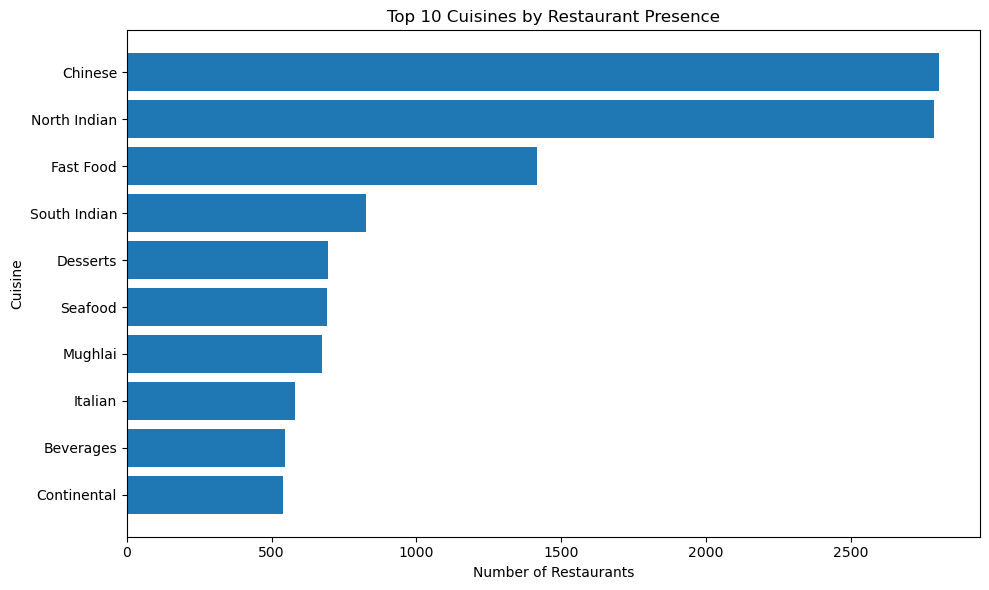

In [46]:
import matplotlib.pyplot as plt

top_cuisines = cuisine_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cuisines["Cuisine"][::-1],
    top_cuisines["Restaurant_Count"][::-1]
)

plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.title("Top 10 Cuisines by Restaurant Presence")

plt.tight_layout()
plt.show()

In [47]:
# Cuisine performance based on rating

cuisine_rating_df = df_clean[["Cuisines", "Rating"]].dropna().copy()

cuisine_rating_df["Cuisine"] = cuisine_rating_df["Cuisines"].str.split(", ")

cuisine_rating_df = cuisine_rating_df.explode("Cuisine")

cuisine_rating = (
    cuisine_rating_df
    .groupby("Cuisine")
    .agg(
        Restaurant_Count=("Rating", "count"),
        Average_Rating=("Rating", "mean")
    )
    .reset_index()
    .sort_values("Restaurant_Count", ascending=False)
)

cuisine_rating.head(15)

,Cuisine,Restaurant_Count,Average_Rating
26,Chinese,2806,3.542730
83,North Indian,2787,3.574345
38,Fast Food,1418,3.590409
101,South Indian,827,3.527328
33,Desserts,695,3.815396
97,Seafood,691,3.593777
80,Mughlai,674,3.572107
57,Italian,580,3.902931
12,Beverages,547,3.674771
29,Continental,538,3.908736


In [48]:
# Location-wise rating analysis

location_rating = (
    df_clean
    .groupby("Restaurant_Location")
    .agg(
        Restaurant_Count=("Rating", "count"),
        Average_Rating=("Rating", "mean")
    )
    .reset_index()
    .sort_values("Restaurant_Count", ascending=False)
)

location_rating.head(15)

,Restaurant_Location,Restaurant_Count,Average_Rating
108,Thane West,360,3.664167
6,Andheri West,242,3.776860
11,Bandra West,204,3.909314
77,Mira Road,196,3.565816
70,Malad West,189,3.632804
15,Borivali West,187,3.709091
22,Chembur,136,3.610294
52,Kalyan,123,3.485366
57,Kandivali West,120,3.610833
34,Dombivali East,120,3.487500


In [49]:
# Reliable location rating comparison

location_rating_reliable = (
    location_rating[
        location_rating["Restaurant_Count"] >= 20
    ]
    .sort_values("Average_Rating", ascending=False)
)

location_rating_reliable.head(15)

,Restaurant_Location,Restaurant_Count,Average_Rating
10,Bandra Kurla Complex,36,4.147222
11,Bandra West,204,3.909314
24,Churchgate,24,3.900000
29,Dadar Shivaji Park,25,3.860000
48,Juhu,94,3.846809
59,Khar,75,3.836000
25,Colaba,78,3.835897
23,Chowpatty,30,3.830000
85,Nariman Point,27,3.829630
74,Matunga East,52,3.821154


In [50]:
# Location-wise popularity analysis

location_popularity = (
    df_clean
    .groupby("Restaurant_Location")
    .agg(
        Restaurant_Count=("Votes", "count"),
        Total_Votes=("Votes", "sum"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
    .sort_values("Total_Votes", ascending=False)
)

location_popularity.head(15)

,Restaurant_Location,Restaurant_Count,Total_Votes,Average_Votes
11,Bandra West,204,127981.0,627.357843
6,Andheri West,242,106350.0,439.462810
108,Thane West,360,74286.0,206.350000
95,Powai,113,73467.0,650.150442
25,Colaba,78,63763.0,817.474359
63,Lower Parel,107,61557.0,575.299065
48,Juhu,94,54965.0,584.734043
15,Borivali West,187,52498.0,280.737968
70,Malad West,189,49430.0,261.534392
37,Fort,92,43050.0,467.934783


In [51]:
# Reliable location popularity comparison

location_popularity_reliable = (
    location_popularity[
        location_popularity["Restaurant_Count"] >= 20
    ]
    .sort_values("Average_Votes", ascending=False)
)

location_popularity_reliable.head(15)

,Restaurant_Location,Restaurant_Count,Total_Votes,Average_Votes
24,Churchgate,24,27277.0,1136.541667
10,Bandra Kurla Complex,36,35115.0,975.416667
25,Colaba,78,63763.0,817.474359
95,Powai,113,73467.0,650.150442
11,Bandra West,204,127981.0,627.357843
113,Veera Desai Area,33,20694.0,627.090909
48,Juhu,94,54965.0,584.734043
29,Dadar Shivaji Park,25,14512.0,580.480000
23,Chowpatty,30,17351.0,578.366667
63,Lower Parel,107,61557.0,575.299065


## Minimum Order Analysis

In [52]:
# Minimum order analysis

minimum_order_summary = (
    df_clean
    .groupby("Restaurant_Location")
    .agg(
        Restaurant_Count=("Min_Order(Rs.)", "count"),
        Average_Min_Order=("Min_Order(Rs.)", "mean"),
        Minimum_Order=("Min_Order(Rs.)", "min"),
        Maximum_Order=("Min_Order(Rs.)", "max")
    )
    .reset_index()
    .sort_values("Restaurant_Count", ascending=False)
)

minimum_order_summary.head(15)

,Restaurant_Location,Restaurant_Count,Average_Min_Order,Minimum_Order,Maximum_Order
6,Andheri West,128,78.945312,0.0,200.0
108,Thane West,105,88.695238,0.0,300.0
11,Bandra West,100,82.930000,0.0,175.0
77,Mira Road,88,78.818182,0.0,250.0
70,Malad West,82,81.573171,0.0,250.0
15,Borivali West,73,80.013699,0.0,99.0
60,Kharghar,58,86.275862,0.0,250.0
34,Dombivali East,56,74.071429,0.0,500.0
95,Powai,55,78.454545,0.0,300.0
22,Chembur,49,86.653061,0.0,480.0


In [53]:
# Reliable minimum order comparison

minimum_order_reliable = (
    minimum_order_summary[
        minimum_order_summary["Restaurant_Count"] >= 20
    ]
    .sort_values("Average_Min_Order", ascending=False)
)

minimum_order_reliable.head(15)

,Restaurant_Location,Restaurant_Count,Average_Min_Order,Minimum_Order,Maximum_Order
88,Nerul,22,94.545455,0.0,199.0
37,Fort,25,91.280000,0.0,300.0
115,Vile Parle East,33,90.242424,0.0,250.0
59,Khar,35,89.171429,0.0,200.0
108,Thane West,105,88.695238,0.0,300.0
63,Lower Parel,39,87.692308,0.0,350.0
22,Chembur,49,86.653061,0.0,480.0
60,Kharghar,58,86.275862,0.0,250.0
64,Mahakali,23,86.217391,0.0,300.0
11,Bandra West,100,82.930000,0.0,175.0


In [54]:
# Home delivery analysis

home_delivery_summary = (
    df_clean["Home_Delivery"]
    .value_counts()
    .reset_index()
)

home_delivery_summary.columns = ["Home_Delivery", "Restaurant_Count"]

home_delivery_summary

,Home_Delivery,Restaurant_Count
0,False,3836
1,True,2088


In [55]:
# Check all column names
df_clean.columns.tolist()

['Call',
 'Cost_for_two',
 'Cuisines',
 'Home_Delivery',
 'Operational_hours',
 'Restaurant_Location',
 'Restaurant_Name',
 'Restaurant_Type',
 'View_Menu',
 'Min_Order(Rs.)',
 'Delivery_Time(mins)',
 'Rating',
 'Votes',
 'Rating_Category',
 'Operational_after_Midnight',
 'Cuisine_count',
 'Feature_Count',
 'Res_Type_Count',
 'Competitors_in_Location',
 'Score',
 'Min_Order_Applicable',
 'Delivery_Time_Applicable',
 'Cost_Band',
 'Popularity_Category']

In [56]:
# Home delivery vs rating

delivery_rating = (
    df_clean
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Rating", "count"),
        Average_Rating=("Rating", "mean")
    )
    .reset_index()
)

delivery_rating

,Home_Delivery,Restaurant_Count,Average_Rating
0,False,3836,3.598931
1,True,2088,3.716284


In [57]:
# Home delivery vs popularity

delivery_votes = (
    df_clean
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Votes", "count"),
        Total_Votes=("Votes", "sum"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
    .sort_values("Average_Votes", ascending=False)
)

delivery_votes

,Home_Delivery,Restaurant_Count,Total_Votes,Average_Votes
1,True,2088,761089.0,364.506226
0,False,3836,879950.0,229.392596


In [58]:
# Location-wise home delivery analysis

location_delivery = (
    df_clean
    .groupby("Restaurant_Location")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Delivery_Restaurants=("Home_Delivery", "sum")
    )
    .reset_index()
)

location_delivery["Delivery_Percentage"] = (
    location_delivery["Delivery_Restaurants"]
    / location_delivery["Restaurant_Count"]
    * 100
)

location_delivery = (
    location_delivery
    .sort_values("Delivery_Percentage", ascending=False)
)

location_delivery.head(15)

,Restaurant_Location,Restaurant_Count,Delivery_Restaurants,Delivery_Percentage
92,Panvel,1,1,100.000000
94,Peddar Road,7,5,71.428571
21,Charni Road,36,23,63.888889
98,Runwal Green,5,3,60.000000
0,4 Bungalows,24,13,54.166667
100,Sanpada,24,13,54.166667
6,Andheri West,242,128,52.892562
20,Chandivali,19,10,52.631579
60,Kharghar,117,58,49.572650
11,Bandra West,204,100,49.019608


In [59]:
# Reliable location delivery comparison

location_delivery_reliable = (
    location_delivery[
        location_delivery["Restaurant_Count"] >= 20
    ]
    .sort_values("Delivery_Percentage", ascending=False)
)

location_delivery_reliable.head(15)

,Restaurant_Location,Restaurant_Count,Delivery_Restaurants,Delivery_Percentage
21,Charni Road,36,23,63.888889
0,4 Bungalows,24,13,54.166667
100,Sanpada,24,13,54.166667
6,Andheri West,242,128,52.892562
60,Kharghar,117,58,49.572650
11,Bandra West,204,100,49.019608
95,Powai,113,55,48.672566
59,Khar,75,35,46.666667
14,Borivali East,30,14,46.666667
34,Dombivali East,120,56,46.666667


In [60]:
# Home delivery vs minimum order

delivery_min_order = (
    df_clean
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Min_Order(Rs.)", "count"),
        Average_Min_Order=("Min_Order(Rs.)", "mean"),
        Minimum_Order=("Min_Order(Rs.)", "min"),
        Maximum_Order=("Min_Order(Rs.)", "max")
    )
    .reset_index()
)

delivery_min_order

,Home_Delivery,Restaurant_Count,Average_Min_Order,Minimum_Order,Maximum_Order
0,False,0,NaN,NaN,NaN
1,True,2088,79.96887,0.0,500.0


In [61]:
# Home delivery vs minimum order

delivery_min_order = (
    df_clean[
        df_clean["Min_Order(Rs.)"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Min_Order(Rs.)", "count"),
        Average_Min_Order=("Min_Order(Rs.)", "mean"),
        Minimum_Order=("Min_Order(Rs.)", "min"),
        Maximum_Order=("Min_Order(Rs.)", "max")
    )
    .reset_index()
)

delivery_min_order

,Home_Delivery,Restaurant_Count,Average_Min_Order,Minimum_Order,Maximum_Order
0,True,2088,79.96887,0.0,500.0


In [62]:
# Minimum order analysis for home-delivery restaurants

home_delivery_min_order = (
    df_clean[
        (df_clean["Home_Delivery"] == True) &
        (df_clean["Min_Order(Rs.)"].notna())
    ]
    .agg(
        Restaurant_Count=("Min_Order(Rs.)", "count"),
        Average_Min_Order=("Min_Order(Rs.)", "mean"),
        Minimum_Order=("Min_Order(Rs.)", "min"),
        Maximum_Order=("Min_Order(Rs.)", "max")
    )
)

home_delivery_min_order

,Min_Order(Rs.)
Restaurant_Count,2088.00000
Average_Min_Order,79.96887
Minimum_Order,0.00000
Maximum_Order,500.00000


In [63]:
# Home delivery vs delivery time

delivery_time = (
    df_clean[
        df_clean["Delivery_Time(mins)"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Delivery_Time(mins)", "count"),
        Average_Delivery_Time=("Delivery_Time(mins)", "mean"),
        Minimum_Delivery_Time=("Delivery_Time(mins)", "min"),
        Maximum_Delivery_Time=("Delivery_Time(mins)", "max")
    )
    .reset_index()
)

delivery_time

,Home_Delivery,Restaurant_Count,Average_Delivery_Time,Minimum_Delivery_Time,Maximum_Delivery_Time
0,True,2088,45.795498,20.0,1440.0


In [64]:
# Home delivery vs late-night operations

home_delivery_midnight = (
    df_clean
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Late_Night_Restaurants=("Operational_after_Midnight", "sum")
    )
    .reset_index()
)

home_delivery_midnight["Late_Night_Percentage"] = (
    home_delivery_midnight["Late_Night_Restaurants"]
    / home_delivery_midnight["Restaurant_Count"]
    * 100
)

home_delivery_midnight = (
    home_delivery_midnight
    .sort_values("Late_Night_Percentage", ascending=False)
)

home_delivery_midnight

,Home_Delivery,Restaurant_Count,Late_Night_Restaurants,Late_Night_Percentage
1,True,2088,483,23.132184
0,False,3836,792,20.646507


In [65]:
# Home delivery vs rating category

home_delivery_rating_category = (
    df_clean
    .groupby(["Home_Delivery", "Rating_Category"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_rating_category["Percentage"] = (
    home_delivery_rating_category["Restaurant_Count"]
    / home_delivery_rating_category.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_rating_category = (
    home_delivery_rating_category
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_rating_category

,Home_Delivery,Rating_Category,Restaurant_Count,Percentage
2,False,Good,1969,51.329510
0,False,Average,1240,32.325339
4,False,Very Good,547,14.259645
1,False,Excellent,69,1.798749
3,False,Poor,11,0.286757
7,True,Good,1065,51.005747
9,True,Very Good,494,23.659004
5,True,Average,463,22.174330
6,True,Excellent,61,2.921456
8,True,Poor,5,0.239464


In [66]:
# Home delivery vs cuisine variety

home_delivery_cuisine = (
    df_clean
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Cuisine_Count=("Cuisine_count", "mean"),
        Minimum_Cuisine_Count=("Cuisine_count", "min"),
        Maximum_Cuisine_Count=("Cuisine_count", "max")
    )
    .reset_index()
)

home_delivery_cuisine

,Home_Delivery,Restaurant_Count,Average_Cuisine_Count,Minimum_Cuisine_Count,Maximum_Cuisine_Count
0,False,3836,2.672054,1,8
1,True,2088,3.051724,1,8


In [67]:
# Home delivery vs popularity

home_delivery_votes = (
    df_clean
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Total_Votes=("Votes", "sum"),
        Average_Votes=("Votes", "mean"),
        Median_Votes=("Votes", "median")
    )
    .reset_index()
    .sort_values("Average_Votes", ascending=False)
)

home_delivery_votes

,Home_Delivery,Restaurant_Count,Total_Votes,Average_Votes,Median_Votes
1,True,2088,761089.0,364.506226,155.0
0,False,3836,879950.0,229.392596,73.0


In [68]:
# Home delivery vs cost band

home_delivery_cost = (
    df_clean
    .groupby(["Home_Delivery", "Cost_Band"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_cost["Percentage"] = (
    home_delivery_cost["Restaurant_Count"]
    / home_delivery_cost.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_cost = (
    home_delivery_cost
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_cost

C:\Users\HP\AppData\Local\Temp\ipykernel_10200\2822019784.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Home_Delivery", "Cost_Band"])


,Home_Delivery,Cost_Band,Restaurant_Count,Percentage
1,False,₹301–500,1293,33.706986
0,False,₹0–300,932,24.296142
2,False,₹501–750,762,19.864442
3,False,₹751–1000,332,8.654849
4,False,₹1001–1500,234,6.100104
5,False,₹1501–2500,159,4.144943
6,False,₹2500+,124,3.232534
8,True,₹301–500,715,34.243295
9,True,₹501–750,518,24.808429
7,True,₹0–300,410,19.636015


In [69]:
# Home delivery vs average cost for two

home_delivery_cost_avg = (
    df_clean[
        df_clean["Cost_for_two"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Cost_for_two", "count"),
        Average_Cost_for_Two=("Cost_for_two", "mean"),
        Median_Cost_for_Two=("Cost_for_two", "median"),
        Minimum_Cost=("Cost_for_two", "min"),
        Maximum_Cost=("Cost_for_two", "max")
    )
    .reset_index()
)

home_delivery_cost_avg

,Home_Delivery,Restaurant_Count,Average_Cost_for_Two,Median_Cost_for_Two,Minimum_Cost,Maximum_Cost
0,False,3836,703.08316,500.0,50,30000
1,True,2088,601.15182,500.0,100,5000


In [70]:
# Home delivery vs cost band

home_delivery_cost = (
    df_clean
    .groupby(["Home_Delivery", "Cost_Band"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_cost["Percentage"] = (
    home_delivery_cost["Restaurant_Count"]
    / home_delivery_cost.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_cost = (
    home_delivery_cost
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_cost

C:\Users\HP\AppData\Local\Temp\ipykernel_10200\2822019784.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Home_Delivery", "Cost_Band"])


,Home_Delivery,Cost_Band,Restaurant_Count,Percentage
1,False,₹301–500,1293,33.706986
0,False,₹0–300,932,24.296142
2,False,₹501–750,762,19.864442
3,False,₹751–1000,332,8.654849
4,False,₹1001–1500,234,6.100104
5,False,₹1501–2500,159,4.144943
6,False,₹2500+,124,3.232534
8,True,₹301–500,715,34.243295
9,True,₹501–750,518,24.808429
7,True,₹0–300,410,19.636015


In [71]:
# Home delivery vs restaurant type

home_delivery_type = (
    df_clean
    .groupby(["Home_Delivery", "Restaurant_Type"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_type["Percentage"] = (
    home_delivery_type["Restaurant_Count"]
    / home_delivery_type.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_type = (
    home_delivery_type
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_type

,Home_Delivery,Restaurant_Type,Restaurant_Count,Percentage
3,False,Casual Dining,1929,50.286757
6,False,Food Court,1060,27.632951
4,False,Dessert,205,5.344108
2,False,CafÃ©,183,4.770594
0,False,Bakery,173,4.509906
1,False,Bar,158,4.118874
5,False,Fine Dining,128,3.336809
10,True,Casual Dining,1004,48.084291
13,True,Food Court,644,30.842912
9,True,CafÃ©,170,8.141762


In [72]:
# Home delivery vs rating category

home_delivery_rating = (
    df_clean
    .groupby(["Home_Delivery", "Rating_Category"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_rating["Percentage"] = (
    home_delivery_rating["Restaurant_Count"]
    / home_delivery_rating.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_rating = (
    home_delivery_rating
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_rating

,Home_Delivery,Rating_Category,Restaurant_Count,Percentage
2,False,Good,1969,51.329510
0,False,Average,1240,32.325339
4,False,Very Good,547,14.259645
1,False,Excellent,69,1.798749
3,False,Poor,11,0.286757
7,True,Good,1065,51.005747
9,True,Very Good,494,23.659004
5,True,Average,463,22.174330
6,True,Excellent,61,2.921456
8,True,Poor,5,0.239464


In [73]:
# Home delivery vs delivery time bands

df_delivery_time = df_clean[
    df_clean["Delivery_Time(mins)"].notna()
].copy()

df_delivery_time["Delivery_Time_Band"] = pd.cut(
    df_delivery_time["Delivery_Time(mins)"],
    bins=[0, 30, 45, 60, 90, float("inf")],
    labels=["≤30 mins", "31–45 mins", "46–60 mins", "61–90 mins", "90+ mins"]
)

home_delivery_time_band = (
    df_delivery_time
    .groupby(["Home_Delivery", "Delivery_Time_Band"], observed=True)
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_time_band["Percentage"] = (
    home_delivery_time_band["Restaurant_Count"]
    / home_delivery_time_band.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_time_band = (
    home_delivery_time_band
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_time_band

,Home_Delivery,Delivery_Time_Band,Restaurant_Count,Percentage
1,True,31–45 mins,1491,71.408046
2,True,46–60 mins,365,17.480843
0,True,≤30 mins,205,9.818008
3,True,61–90 mins,17,0.814176
4,True,90+ mins,10,0.478927


In [74]:
# Home delivery vs minimum order

home_delivery_min_order = (
    df_clean[
        df_clean["Min_Order(Rs.)"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Min_Order=("Min_Order(Rs.)", "mean"),
        Median_Min_Order=("Min_Order(Rs.)", "median"),
        Minimum_Min_Order=("Min_Order(Rs.)", "min"),
        Maximum_Min_Order=("Min_Order(Rs.)", "max")
    )
    .reset_index()
)

home_delivery_min_order

,Home_Delivery,Restaurant_Count,Average_Min_Order,Median_Min_Order,Minimum_Min_Order,Maximum_Min_Order
0,True,2088,79.96887,99.0,0.0,500.0


In [75]:
# Home delivery vs minimum order applicability

home_delivery_min_order_applicable = (
    df_clean
    .groupby(["Home_Delivery", "Min_Order_Applicable"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_min_order_applicable["Percentage"] = (
    home_delivery_min_order_applicable["Restaurant_Count"]
    / home_delivery_min_order_applicable.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_min_order_applicable = (
    home_delivery_min_order_applicable
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_min_order_applicable

,Home_Delivery,Min_Order_Applicable,Restaurant_Count,Percentage
0,False,False,3836,100.0
1,True,True,2088,100.0


In [76]:
# Home delivery vs delivery time applicability

home_delivery_delivery_time_applicable = (
    df_clean
    .groupby(["Home_Delivery", "Delivery_Time_Applicable"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_delivery_time_applicable["Percentage"] = (
    home_delivery_delivery_time_applicable["Restaurant_Count"]
    / home_delivery_delivery_time_applicable
        .groupby("Home_Delivery")["Restaurant_Count"]
        .transform("sum")
    * 100
)

home_delivery_delivery_time_applicable = (
    home_delivery_delivery_time_applicable
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_delivery_time_applicable

,Home_Delivery,Delivery_Time_Applicable,Restaurant_Count,Percentage
0,False,False,3836,100.0
1,True,True,2088,100.0


In [77]:
# Home delivery vs restaurant location

home_delivery_location = (
    df_clean
    .groupby(["Home_Delivery", "Restaurant_Location"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_location["Percentage"] = (
    home_delivery_location["Restaurant_Count"]
    / home_delivery_location
        .groupby("Home_Delivery")["Restaurant_Count"]
        .transform("sum")
    * 100
)

home_delivery_location = (
    home_delivery_location
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_location

,Home_Delivery,Restaurant_Location,Restaurant_Count,Percentage
107,False,Thane West,255,6.647550
6,False,Andheri West,114,2.971846
15,False,Borivali West,114,2.971846
77,False,Mira Road,108,2.815433
70,False,Malad West,107,2.789364
...,...,...,...,...
148,True,Flea Bazaar CafÃ©,1,0.047893
163,True,Kalwa,1,0.047893
178,True,Malabar Hill,1,0.047893
200,True,Panvel,1,0.047893


In [78]:
# Home delivery vs operational after midnight

home_delivery_midnight = (
    df_clean
    .groupby(["Home_Delivery", "Operational_after_Midnight"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_midnight["Percentage"] = (
    home_delivery_midnight["Restaurant_Count"]
    / home_delivery_midnight.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_midnight = (
    home_delivery_midnight
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_midnight

,Home_Delivery,Operational_after_Midnight,Restaurant_Count,Percentage
0,False,False,3044,79.353493
1,False,True,792,20.646507
2,True,False,1605,76.867816
3,True,True,483,23.132184


In [79]:
# Home delivery vs average rating

home_delivery_rating_avg = (
    df_clean[
        df_clean["Rating"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median"),
        Minimum_Rating=("Rating", "min"),
        Maximum_Rating=("Rating", "max")
    )
    .reset_index()
)

home_delivery_rating_avg

,Home_Delivery,Restaurant_Count,Average_Rating,Median_Rating,Minimum_Rating,Maximum_Rating
0,False,3836,3.598931,3.6,2.0,4.9
1,True,2088,3.716284,3.7,2.1,4.8


In [80]:
# Home delivery vs popularity category

home_delivery_popularity = (
    df_clean
    .groupby(["Home_Delivery", "Popularity_Category"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_popularity["Percentage"] = (
    home_delivery_popularity["Restaurant_Count"]
    / home_delivery_popularity.groupby("Home_Delivery")["Restaurant_Count"].transform("sum")
    * 100
)

home_delivery_popularity = (
    home_delivery_popularity
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_popularity

C:\Users\HP\AppData\Local\Temp\ipykernel_10200\2800666416.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Home_Delivery", "Popularity_Category"])


,Home_Delivery,Popularity_Category,Restaurant_Count,Percentage
0,False,Low,1548,40.354536
1,False,Moderate,1267,33.029197
2,False,High,580,15.119917
3,False,Very High,441,11.496350
5,True,Moderate,747,35.775862
6,True,High,505,24.185824
4,True,Low,435,20.833333
7,True,Very High,401,19.204981


In [81]:
# Home delivery vs score

home_delivery_score = (
    df_clean[
        df_clean["Score"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Score=("Score", "mean"),
        Median_Score=("Score", "median"),
        Minimum_Score=("Score", "min"),
        Maximum_Score=("Score", "max")
    )
    .reset_index()
)

home_delivery_score

,Home_Delivery,Restaurant_Count,Average_Score,Median_Score,Minimum_Score,Maximum_Score
0,False,3836,23.428335,22.534269,1.057508,75.784484
1,True,2088,25.863467,24.981680,1.729799,90.344828


In [82]:
# Home delivery vs votes

home_delivery_votes = (
    df_clean[
        df_clean["Votes"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Votes=("Votes", "mean"),
        Median_Votes=("Votes", "median"),
        Minimum_Votes=("Votes", "min"),
        Maximum_Votes=("Votes", "max")
    )
    .reset_index()
)

home_delivery_votes

,Home_Delivery,Restaurant_Count,Average_Votes,Median_Votes,Minimum_Votes,Maximum_Votes
0,False,3836,229.392596,73.0,2.0,7065.0
1,True,2088,364.506226,155.0,4.0,9931.0


In [83]:
# Home delivery vs cuisine count

home_delivery_cuisine_count = (
    df_clean[
        df_clean["Cuisine_count"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Cuisine_Count=("Cuisine_count", "mean"),
        Median_Cuisine_Count=("Cuisine_count", "median"),
        Minimum_Cuisine_Count=("Cuisine_count", "min"),
        Maximum_Cuisine_Count=("Cuisine_count", "max")
    )
    .reset_index()
)

home_delivery_cuisine_count

,Home_Delivery,Restaurant_Count,Average_Cuisine_Count,Median_Cuisine_Count,Minimum_Cuisine_Count,Maximum_Cuisine_Count
0,False,3836,2.672054,2.0,1,8
1,True,2088,3.051724,3.0,1,8


In [84]:
# Home delivery vs feature count

home_delivery_feature_count = (
    df_clean[
        df_clean["Feature_Count"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Feature_Count=("Feature_Count", "mean"),
        Median_Feature_Count=("Feature_Count", "median"),
        Minimum_Feature_Count=("Feature_Count", "min"),
        Maximum_Feature_Count=("Feature_Count", "max")
    )
    .reset_index()
)

home_delivery_feature_count

,Home_Delivery,Restaurant_Count,Average_Feature_Count,Median_Feature_Count,Minimum_Feature_Count,Maximum_Feature_Count
0,False,3836,1.051616,1.0,1,6
1,True,2088,1.071360,1.0,1,6


In [85]:
# ============================================================
# HOME DELIVERY ANALYSIS
# ============================================================

# 1. Home delivery vs minimum order
home_delivery_min_order = (
    df_clean[
        df_clean["Min_Order(Rs.)"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Min_Order=("Min_Order(Rs.)", "mean"),
        Median_Min_Order=("Min_Order(Rs.)", "median"),
        Minimum_Min_Order=("Min_Order(Rs.)", "min"),
        Maximum_Min_Order=("Min_Order(Rs.)", "max")
    )
    .reset_index()
)

home_delivery_min_order


# 2. Home delivery vs minimum order applicability
home_delivery_min_order_applicable = (
    df_clean
    .groupby(["Home_Delivery", "Min_Order_Applicable"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_min_order_applicable["Percentage"] = (
    home_delivery_min_order_applicable["Restaurant_Count"]
    / home_delivery_min_order_applicable
        .groupby("Home_Delivery")["Restaurant_Count"]
        .transform("sum")
    * 100
)

home_delivery_min_order_applicable = (
    home_delivery_min_order_applicable
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_min_order_applicable


# 3. Home delivery vs delivery time applicability
home_delivery_delivery_time_applicable = (
    df_clean
    .groupby(["Home_Delivery", "Delivery_Time_Applicable"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_delivery_time_applicable["Percentage"] = (
    home_delivery_delivery_time_applicable["Restaurant_Count"]
    / home_delivery_delivery_time_applicable
        .groupby("Home_Delivery")["Restaurant_Count"]
        .transform("sum")
    * 100
)

home_delivery_delivery_time_applicable = (
    home_delivery_delivery_time_applicable
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_delivery_time_applicable


# 4. Home delivery vs restaurant location
home_delivery_location = (
    df_clean
    .groupby(["Home_Delivery", "Restaurant_Location"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_location["Percentage"] = (
    home_delivery_location["Restaurant_Count"]
    / home_delivery_location
        .groupby("Home_Delivery")["Restaurant_Count"]
        .transform("sum")
    * 100
)

home_delivery_location = (
    home_delivery_location
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_location


# 5. Home delivery vs operational after midnight
home_delivery_midnight = (
    df_clean
    .groupby(["Home_Delivery", "Operational_after_Midnight"])
    .size()
    .reset_index(name="Restaurant_Count")
)

home_delivery_midnight["Percentage"] = (
    home_delivery_midnight["Restaurant_Count"]
    / home_delivery_midnight
        .groupby("Home_Delivery")["Restaurant_Count"]
        .transform("sum")
    * 100
)

home_delivery_midnight = (
    home_delivery_midnight
    .sort_values(
        ["Home_Delivery", "Percentage"],
        ascending=[True, False]
    )
)

home_delivery_midnight


# 6. Home delivery vs average rating
home_delivery_rating_avg = (
    df_clean[
        df_clean["Rating"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median"),
        Minimum_Rating=("Rating", "min"),
        Maximum_Rating=("Rating", "max")
    )
    .reset_index()
)

home_delivery_rating_avg


# 7. Home delivery vs score
home_delivery_score = (
    df_clean[
        df_clean["Score"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Score=("Score", "mean"),
        Median_Score=("Score", "median"),
        Minimum_Score=("Score", "min"),
        Maximum_Score=("Score", "max")
    )
    .reset_index()
)

home_delivery_score


# 8. Home delivery vs votes
home_delivery_votes = (
    df_clean[
        df_clean["Votes"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Votes=("Votes", "mean"),
        Median_Votes=("Votes", "median"),
        Minimum_Votes=("Votes", "min"),
        Maximum_Votes=("Votes", "max")
    )
    .reset_index()
)

home_delivery_votes


# 9. Home delivery vs cuisine count
home_delivery_cuisine_count = (
    df_clean[
        df_clean["Cuisine_count"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Cuisine_Count=("Cuisine_count", "mean"),
        Median_Cuisine_Count=("Cuisine_count", "median"),
        Minimum_Cuisine_Count=("Cuisine_count", "min"),
        Maximum_Cuisine_Count=("Cuisine_count", "max")
    )
    .reset_index()
)

home_delivery_cuisine_count


# 10. Home delivery vs feature count
home_delivery_feature_count = (
    df_clean[
        df_clean["Feature_Count"].notna()
    ]
    .groupby("Home_Delivery")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Feature_Count=("Feature_Count", "mean"),
        Median_Feature_Count=("Feature_Count", "median"),
        Minimum_Feature_Count=("Feature_Count", "min"),
        Maximum_Feature_Count=("Feature_Count", "max")
    )
    .reset_index()
)

home_delivery_feature_count

,Home_Delivery,Restaurant_Count,Average_Feature_Count,Median_Feature_Count,Minimum_Feature_Count,Maximum_Feature_Count
0,False,3836,1.051616,1.0,1,6
1,True,2088,1.071360,1.0,1,6


In [86]:
# 11. Rating vs votes

rating_vs_votes = (
    df_clean[
        df_clean["Rating"].notna() &
        df_clean["Votes"].notna()
    ]
    .groupby("Rating")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Votes=("Votes", "mean"),
        Median_Votes=("Votes", "median"),
        Minimum_Votes=("Votes", "min"),
        Maximum_Votes=("Votes", "max")
    )
    .reset_index()
)

rating_vs_votes

,Rating,Restaurant_Count,Average_Votes,Median_Votes,Minimum_Votes,Maximum_Votes
0,2.0,3,307.666667,368.0,177.0,378.0
1,2.1,3,70.333333,60.0,59.0,92.0
2,2.2,2,120.000000,120.0,112.0,128.0
3,2.3,3,197.666667,176.0,45.0,372.0
4,2.4,5,109.800000,72.0,57.0,202.0
5,2.5,13,78.000000,61.0,33.0,168.0
6,2.6,28,82.464286,54.0,11.0,207.0
7,2.7,55,95.800000,56.0,10.0,619.0
8,2.8,88,57.295455,40.0,5.0,240.0
9,2.9,112,72.321429,36.0,4.0,1096.0


In [87]:
# 2. Cost Band vs Rating and Score

cost_rating_score = (
    df_clean[
        df_clean["Rating"].notna() &
        df_clean["Score"].notna()
    ]
    .groupby("Cost_Band")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median"),
        Average_Score=("Score", "mean"),
        Median_Score=("Score", "median")
    )
    .reset_index()
)

cost_rating_score

C:\Users\HP\AppData\Local\Temp\ipykernel_10200\3805253456.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Cost_Band")


,Cost_Band,Restaurant_Count,Average_Rating,Median_Rating,Average_Score,Median_Score
0,₹0–300,1342,3.573845,3.6,22.398751,22.223060
1,₹301–500,2008,3.533466,3.5,21.979752,22.189824
2,₹501–750,1280,3.604141,3.6,23.682428,23.635606
3,₹751–1000,573,3.787435,3.8,27.471118,26.906345
4,₹1001–1500,384,3.966927,3.9,32.178639,30.825968
5,₹1501–2500,211,4.054502,4.1,34.296497,33.014263
6,₹2500+,126,4.059524,4.1,31.999444,31.594181


In [88]:
# 3. Cuisine vs Rating and Popularity

cuisine_performance = (
    df_clean[
        df_clean["Rating"].notna() &
        df_clean["Votes"].notna()
    ]
    .groupby("Cuisines")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

# Keep cuisines with at least 10 restaurants
cuisine_performance = (
    cuisine_performance[cuisine_performance["Restaurant_Count"] >= 10]
    .sort_values(
        ["Average_Rating", "Average_Votes"],
        ascending=[False, False]
    )
)

cuisine_performance.head(15)

,Cuisines,Restaurant_Count,Average_Rating,Average_Votes
1561,"North Indian, Continental, Chinese",12,4.066667,774.916667
634,Continental,11,4.018182,805.818182
287,"Cafe, Desserts",16,3.943750,719.125000
777,"Desserts, Beverages",14,3.921429,117.571429
1142,"Italian, Pizza",12,3.916667,1062.166667
1557,"North Indian, Continental",12,3.866667,332.000000
1426,"North Indian, Chinese, Continental",25,3.836000,411.640000
1079,Italian,24,3.825000,383.083333
1772,Pizza,17,3.805882,598.882353
772,"Desserts, Bakery",39,3.800000,213.641026


In [89]:
# 4. Location vs Rating and Popularity

location_performance = (
    df_clean[
        df_clean["Rating"].notna() &
        df_clean["Votes"].notna()
    ]
    .groupby("Restaurant_Location")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

# Keep locations with at least 10 restaurants
location_performance = (
    location_performance[
        location_performance["Restaurant_Count"] >= 10
    ]
    .sort_values(
        ["Average_Rating", "Average_Votes"],
        ascending=[False, False]
    )
)

location_performance.head(15)

,Restaurant_Location,Restaurant_Count,Average_Rating,Average_Votes
54,Kamala Mills Compound,19,4.289474,1077.894737
10,Bandra Kurla Complex,36,4.147222,975.416667
11,Bandra West,204,3.909314,627.357843
24,Churchgate,24,3.900000,1136.541667
29,Dadar Shivaji Park,25,3.860000,580.480000
48,Juhu,94,3.846809,584.734043
26,Cuffe Parade,12,3.841667,458.166667
59,Khar,75,3.836000,525.133333
25,Colaba,78,3.835897,817.474359
23,Chowpatty,30,3.830000,578.366667


In [90]:
# 5. Top 10 restaurants based on Rating + Votes

top_restaurants = (
    df_clean[
        df_clean["Rating"].notna() &
        df_clean["Votes"].notna()
    ][
        ["Restaurant_Name", "Restaurant_Location", "Rating", "Votes", "Cost_Band"]
    ]
    .copy()
)

# Normalize Rating and Votes
top_restaurants["Rating_Score"] = (
    top_restaurants["Rating"] / top_restaurants["Rating"].max()
)

top_restaurants["Vote_Score"] = (
    top_restaurants["Votes"] / top_restaurants["Votes"].max()
)

# Combined score: 70% Rating + 30% Popularity
top_restaurants["Overall_Score"] = (
    0.7 * top_restaurants["Rating_Score"] +
    0.3 * top_restaurants["Vote_Score"]
)

top_10_restaurants = (
    top_restaurants
    .sort_values("Overall_Score", ascending=False)
    .head(10)
)

top_10_restaurants

,Restaurant_Name,Restaurant_Location,Rating,Votes,Cost_Band,Rating_Score,Vote_Score,Overall_Score
552,Candies,Bandra West,4.2,9931.0,₹501–750,0.857143,1.000000,0.900000
3055,Mirchi And Mime,Powai,4.9,5508.0,₹1001–1500,1.000000,0.554627,0.866388
635,Prithvi Cafe,Juhu,4.4,7065.0,₹501–750,0.897959,0.711409,0.841994
5243,Joey's Pizza,Malad West,4.6,5974.0,₹751–1000,0.938776,0.601551,0.837608
3100,Chili's American Grill & Bar,Powai,4.3,6746.0,₹1001–1500,0.877551,0.679287,0.818072
4106,Yauatcha,Bandra Kurla Complex,4.7,4752.0,₹2500+,0.959184,0.478502,0.814979
2636,Hotel Ram Ashraya,Matunga East,4.7,4523.0,₹0–300,0.959184,0.455443,0.808061
4107,Masala Library,Bandra Kurla Complex,4.8,3767.0,₹2500+,0.979592,0.379317,0.799509
392,Tamasha,Lower Parel,4.9,3275.0,₹1501–2500,1.000000,0.329775,0.798933
287,BKC | DIVE.,Bandra Kurla Complex,4.7,4145.0,₹751–1000,0.959184,0.417380,0.796643


### Key Insight 1: Price and Restaurant Quality

Higher-priced restaurants tend to receive better ratings and scores in the dataset. The average rating increases from 3.57 in the ₹0–300 cost band to approximately 4.05–4.06 in the ₹1,501–2,500 and ₹2,500+ bands.

This suggests a positive relationship between restaurant pricing and perceived quality, although higher price does not necessarily guarantee a better customer experience.

### Key Insight 2: Rating and Popularity

Restaurant rating and popularity do not always move together. Some highly rated restaurants have relatively fewer votes, while restaurants with slightly lower ratings can attract substantially more customer engagement.

This indicates that customer satisfaction and restaurant popularity should be evaluated separately rather than using rating alone as a measure of overall performance.

### Key Insight 3: Cuisine Performance

Restaurant performance varies across cuisines. The cuisine-level analysis shows differences in both average customer ratings and average vote counts.

This suggests that cuisine type can be associated with differences in customer satisfaction and engagement. However, the number of restaurants within each cuisine should also be considered when comparing performance.

### Key Insight 4: Location Performance

Restaurant performance varies across locations, with differences in both average ratings and customer engagement.

The location-level analysis indicates that some areas have restaurants with stronger average ratings and higher customer interaction. This suggests that location can be an important factor when evaluating restaurant performance and identifying potentially attractive areas for restaurant businesses.

However, the number of restaurants in each location should be considered when interpreting these comparisons.

### Key Insight 5: Top Performing Restaurants

The top-10 ranking identifies restaurants that perform strongly across both customer ratings and customer engagement. The ranking uses a combined score that gives 70% weight to Rating and 30% weight to Votes.

This approach provides a more balanced view of restaurant performance than relying on ratings or popularity alone. Restaurants appearing in the top rankings demonstrate a strong combination of customer satisfaction and customer engagement.

In [91]:
sorted(df_clean["Restaurant_Location"].dropna().unique())

['4 Bungalows',
 'Airoli',
 'Alibaug',
 'Ambernath',
 'Andheri',
 'Andheri East',
 'Andheri West',
 'Azad Nagar',
 'Bandra',
 'Bandra East',
 'Bandra Kurla Complex',
 'Bandra West',
 'Bhandup',
 'Bhayandar',
 'Borivali East',
 'Borivali West',
 'Breach Candy',
 'Byculla',
 'CBD-Belapur',
 'Chakala',
 'Chandivali',
 'Charni Road',
 'Chembur',
 'Chowpatty',
 'Churchgate',
 'Colaba',
 'Cuffe Parade',
 'Dadar',
 'Dadar East',
 'Dadar Shivaji Park',
 'Dadar West',
 'Dahisar East',
 'Dahisar West',
 'Dombivali',
 'Dombivali East',
 'Dombivali West',
 'Flea Bazaar CafÃ©',
 'Fort',
 'Ghansoli',
 'Ghatkopar East',
 'Ghatkopar West',
 'Ghodbunder Road',
 'Girgaum',
 'Gorai',
 'Goregaon East',
 'Goregaon West',
 'Grant Road',
 'Jogeshwari',
 'Juhu',
 'Kalamboli',
 'Kalbadevi',
 'Kalwa',
 'Kalyan',
 'Kalyan West',
 'Kamala Mills Compound',
 'Kamothe',
 'Kandivali East',
 'Kandivali West',
 'Kemps Corner',
 'Khar',
 'Kharghar',
 'Kopar Khairane',
 'Kurla',
 'Lower Parel',
 'Mahakali',
 'Mahalaxmi',

In [92]:
# Create City classification from Restaurant_Location

navi_mumbai_locations = [
    "Airoli",
    "CBD-Belapur",
    "Ghansoli",
    "Kalamboli",
    "Kamothe",
    "Kharghar",
    "Kopar Khairane",
    "Nerul",
    "New Panvel",
    "Old Panvel",
    "Panvel",
    "Sanpada",
    "Seawoods",
    "Turbhe",
    "Vashi"
]

thane_locations = [
    "Thane East",
    "Thane West",
    "Ghodbunder Road",
    "Majiwada",
    "Panch Pakhadi",
    "Kalwa",
    "Mumbra",
    "Runwal Green"
]

def classify_city(location):
    if location in navi_mumbai_locations:
        return "Navi Mumbai"
    elif location in thane_locations:
        return "Thane"
    elif pd.isna(location):
        return "Unknown"
    else:
        return "Mumbai / Other MMR"

df_clean["City"] = df_clean["Restaurant_Location"].apply(classify_city)

df_clean["City"].value_counts()

City
Mumbai / Other MMR    4840
Navi Mumbai            653
Thane                  431
Name: count, dtype: int64

In [93]:
# 1. City vs Rating and Popularity

city_performance = (
    df_clean[
        df_clean["Rating"].notna() &
        df_clean["Votes"].notna()
    ]
    .groupby("City")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median"),
        Average_Votes=("Votes", "mean"),
        Median_Votes=("Votes", "median")
    )
    .reset_index()
    .sort_values("Average_Rating", ascending=False)
)

city_performance

,City,Restaurant_Count,Average_Rating,Median_Rating,Average_Votes,Median_Votes
0,Mumbai / Other MMR,4840,3.655021,3.7,298.067975,104.0
2,Thane,431,3.648260,3.6,197.030162,84.0
1,Navi Mumbai,653,3.525881,3.5,173.767228,72.0


In [94]:
# 2. City vs Price

city_price = (
    df_clean[
        df_clean["Cost_for_two"].notna()
    ]
    .groupby("City")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Cost_for_Two=("Cost_for_two", "mean"),
        Median_Cost_for_Two=("Cost_for_two", "median"),
        Minimum_Cost_for_Two=("Cost_for_two", "min"),
        Maximum_Cost_for_Two=("Cost_for_two", "max")
    )
    .reset_index()
    .sort_values("Average_Cost_for_Two", ascending=False)
)

city_price

,City,Restaurant_Count,Average_Cost_for_Two,Median_Cost_for_Two,Minimum_Cost_for_Two,Maximum_Cost_for_Two
0,Mumbai / Other MMR,4840,693.101653,500.0,50,30000
2,Thane,431,560.603248,500.0,100,3000
1,Navi Mumbai,653,545.176110,500.0,100,3000


In [95]:
# 3. City vs Home Delivery

city_delivery = (
    df_clean
    .groupby("City")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Home_Delivery_Rate=("Home_Delivery", "mean")
    )
    .reset_index()
)

city_delivery["Home_Delivery_Rate"] = (
    city_delivery["Home_Delivery_Rate"] * 100
)

city_delivery = city_delivery.sort_values(
    "Home_Delivery_Rate",
    ascending=False
)

city_delivery

,City,Restaurant_Count,Home_Delivery_Rate
1,Navi Mumbai,653,42.419602
0,Mumbai / Other MMR,4840,35.020661
2,Thane,431,26.914153


In [96]:
# 4. City vs Restaurant Type

city_restaurant_type = (
    df_clean
    .groupby(["City", "Restaurant_Type"])
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

city_restaurant_type = (
    city_restaurant_type[
        city_restaurant_type["Restaurant_Count"] >= 10
    ]
    .sort_values(
        ["City", "Restaurant_Count"],
        ascending=[True, False]
    )
)

city_restaurant_type

,City,Restaurant_Type,Restaurant_Count,Average_Rating,Average_Votes
3,Mumbai / Other MMR,Casual Dining,2343,3.628510,352.682458
6,Mumbai / Other MMR,Food Court,1379,3.568600,154.412618
4,Mumbai / Other MMR,Dessert,301,3.746844,157.455150
2,Mumbai / Other MMR,CafÃ©,298,3.797651,413.342282
0,Mumbai / Other MMR,Bakery,227,3.700881,136.555066
1,Mumbai / Other MMR,Bar,164,3.906098,724.304878
5,Mumbai / Other MMR,Fine Dining,128,4.120312,648.632812
10,Navi Mumbai,Casual Dining,353,3.526912,218.747875
13,Navi Mumbai,Food Court,195,3.435897,99.707692
9,Navi Mumbai,CafÃ©,36,3.702778,190.250000


In [97]:
# 5. Cuisine Performance: Rating vs Popularity

cuisine_performance = (
    df_clean[
        df_clean["Rating"].notna() &
        df_clean["Votes"].notna()
    ]
    .groupby("Cuisines")
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median"),
        Average_Votes=("Votes", "mean"),
        Median_Votes=("Votes", "median")
    )
    .reset_index()
)

# Keep cuisines with at least 20 restaurants
cuisine_performance = (
    cuisine_performance[
        cuisine_performance["Restaurant_Count"] >= 20
    ]
    .sort_values(
        ["Average_Rating", "Average_Votes"],
        ascending=[False, False]
    )
)

cuisine_performance.head(20)

,Cuisines,Restaurant_Count,Average_Rating,Median_Rating,Average_Votes,Median_Votes
1426,"North Indian, Chinese, Continental",25,3.836000,3.80,411.640000,228.0
1079,Italian,24,3.825000,3.90,383.083333,217.5
772,"Desserts, Bakery",39,3.800000,3.80,213.641026,70.0
771,Desserts,71,3.795775,3.70,117.619718,54.0
100,"Bakery, Desserts",147,3.759864,3.70,133.700680,62.0
1900,South Indian,55,3.747273,3.70,361.763636,99.0
1060,"Ice Cream, Desserts",25,3.736000,3.70,132.240000,55.0
787,"Desserts, Ice Cream",52,3.721154,3.70,157.634615,50.0
1653,"North Indian, Mughlai",42,3.711905,3.80,596.142857,144.5
103,"Bakery, Desserts, Fast Food",22,3.695455,3.70,237.045455,87.0


In [98]:
# RQ8: Cuisine × City Market Gaps

cuisine_city = (
    df_clean[
        df_clean["Cuisines"].notna() &
        df_clean["City"].notna() &
        df_clean["Rating"].notna() &
        df_clean["Votes"].notna()
    ]
    .groupby(["City", "Cuisines"])
    .agg(
        Restaurant_Count=("Restaurant_Name", "count"),
        Average_Rating=("Rating", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

# Keep cuisine-city combinations with at least 5 restaurants
cuisine_city = cuisine_city[
    cuisine_city["Restaurant_Count"] >= 5
]

cuisine_city = cuisine_city.sort_values(
    ["City", "Average_Votes"],
    ascending=[True, False]
)

cuisine_city.head(20)

,City,Cuisines,Restaurant_Count,Average_Rating,Average_Votes
1139,Mumbai / Other MMR,Modern Indian,7,4.385714,1497.428571
931,Mumbai / Other MMR,"Italian, Continental",5,4.100000,1118.600000
973,Mumbai / Other MMR,"Italian, Pizza",12,3.916667,1062.166667
532,Mumbai / Other MMR,Continental,10,4.070000,884.200000
235,Mumbai / Other MMR,"Cafe, Desserts",15,3.986667,766.533333
1531,Mumbai / Other MMR,Pizza,13,3.876923,712.846154
1420,Mumbai / Other MMR,"North Indian, Mughlai",38,3.734211,625.605263
246,Mumbai / Other MMR,"Cafe, Fast Food",15,3.566667,584.133333
1343,Mumbai / Other MMR,"North Indian, Continental, Chinese",8,4.150000,581.375000
524,Mumbai / Other MMR,"Chinese, Thai, Seafood",5,3.720000,558.200000


In [102]:
# RQ9: Market Opportunity Analysis

opportunity = cuisine_city.copy()

# Demand score: higher average votes = higher demand
opportunity["Demand_Score"] = (
    opportunity.groupby("City")["Average_Votes"]
    .transform(
        lambda x: (x - x.min()) / (x.max() - x.min())
        if x.max() != x.min() else 0
    )
)

# Scarcity score: fewer restaurants = higher opportunity
opportunity["Scarcity_Score"] = (
    opportunity.groupby("City")["Restaurant_Count"]
    .transform(
        lambda x: 1 - ((x - x.min()) / (x.max() - x.min()))
        if x.max() != x.min() else 0
    )
)

# Combined opportunity score
opportunity["Opportunity_Score"] = (
    0.6 * opportunity["Demand_Score"] +
    0.4 * opportunity["Scarcity_Score"]
)

# Highest opportunity first
opportunity = opportunity.sort_values(
    "Opportunity_Score",
    ascending=False
)

opportunity.head(20)

,City,Cuisines,Restaurant_Count,Average_Rating,Average_Votes,Demand_Score,Scarcity_Score,Opportunity_Score
1139,Mumbai / Other MMR,Modern Indian,7,4.385714,1497.428571,1.000000,0.990050,0.996020
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",9,3.388889,218.000000,1.000000,0.894737,0.957895
2274,Thane,Maharashtrian,8,3.950000,386.875000,1.000000,0.884615,0.953846
931,Mumbai / Other MMR,"Italian, Continental",5,4.100000,1118.600000,0.742088,1.000000,0.845253
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",9,3.522222,171.000000,0.757231,0.894737,0.812234
973,Mumbai / Other MMR,"Italian, Pizza",12,3.916667,1062.166667,0.703667,0.965174,0.808270
1888,Navi Mumbai,"Chinese, North Indian, Seafood",5,3.260000,151.600000,0.657025,1.000000,0.794215
2037,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",5,3.580000,134.600000,0.569215,1.000000,0.741529
532,Mumbai / Other MMR,Continental,10,4.070000,884.200000,0.582505,0.975124,0.739553
2297,Thane,North Indian,10,3.620000,272.400000,0.659491,0.807692,0.718771


In [101]:
df_clean.columns

Index(['Call', 'Cost_for_two', 'Cuisines', 'Home_Delivery',
       'Operational_hours', 'Restaurant_Location', 'Restaurant_Name',
       'Restaurant_Type', 'View_Menu', 'Min_Order(Rs.)', 'Delivery_Time(mins)',
       'Rating', 'Votes', 'Rating_Category', 'Operational_after_Midnight',
       'Cuisine_count', 'Feature_Count', 'Res_Type_Count',
       'Competitors_in_Location', 'Score', 'Min_Order_Applicable',
       'Delivery_Time_Applicable', 'Cost_Band', 'Popularity_Category', 'City'],
      dtype='object')

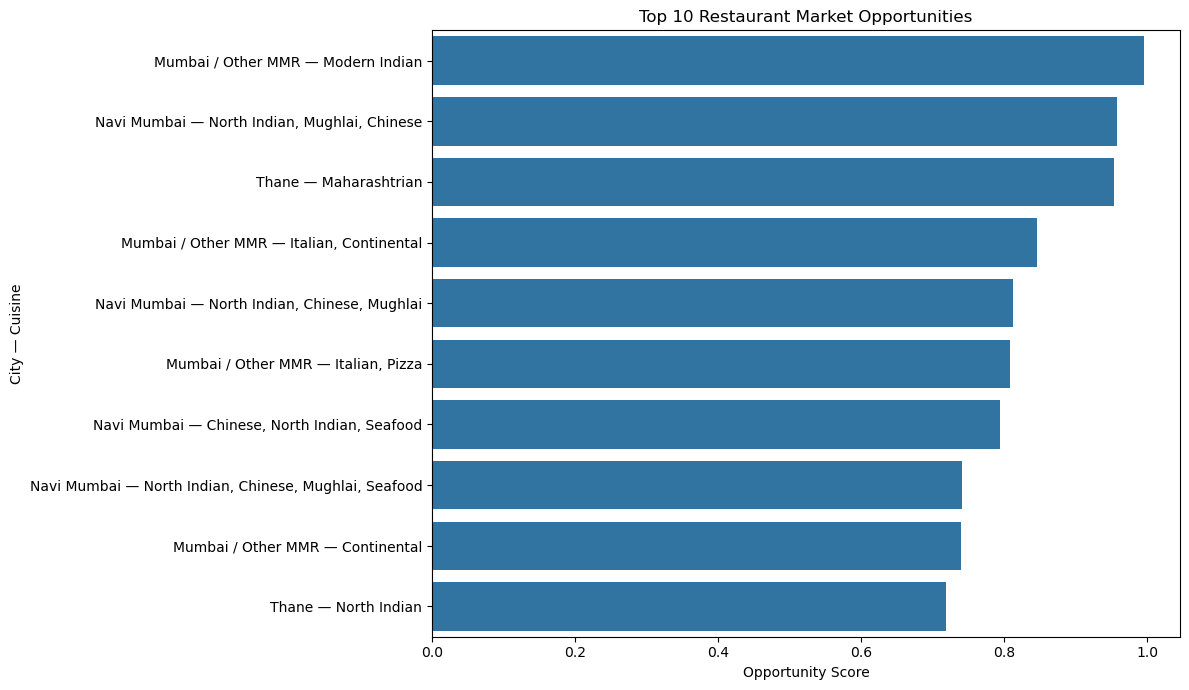

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

top_opportunities = opportunity.head(10).copy()

top_opportunities["Label"] = (
    top_opportunities["City"] 
    + " — " 
    + top_opportunities["Cuisines"]
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_opportunities,
    x="Opportunity_Score",
    y="Label"
)

plt.title("Top 10 Restaurant Market Opportunities")
plt.xlabel("Opportunity Score")
plt.ylabel("City — Cuisine")
plt.tight_layout()

plt.show()

In [105]:
# Expand cuisines so each cuisine gets its own row

cuisine_city_expanded = df_clean[
    ["City", "Cuisines"]
].copy()

cuisine_city_expanded["Cuisines"] = (
    cuisine_city_expanded["Cuisines"]
    .str.split(", ")
)

cuisine_city_expanded = cuisine_city_expanded.explode("Cuisines")

cuisine_city_expanded.head()

,City,Cuisines
0,Navi Mumbai,Bakery
1,Navi Mumbai,Bakery
1,Navi Mumbai,Desserts
2,Navi Mumbai,Bakery
3,Navi Mumbai,Cafe


In [106]:
# Cuisine supply by city

cuisine_supply = pd.crosstab(
    cuisine_city_expanded["Cuisines"],
    cuisine_city_expanded["City"]
)

cuisine_supply.head(10)

City,Mumbai / Other MMR,Navi Mumbai,Thane
Cuisines,,,
Afghani,9,1,0
American,97,13,13
Andhra,5,0,0
Arabian,11,1,1
Asian,149,11,7
Asian Fusion,3,0,0
Awadhi,7,0,2
BBQ,27,1,3
Bakery,311,36,19


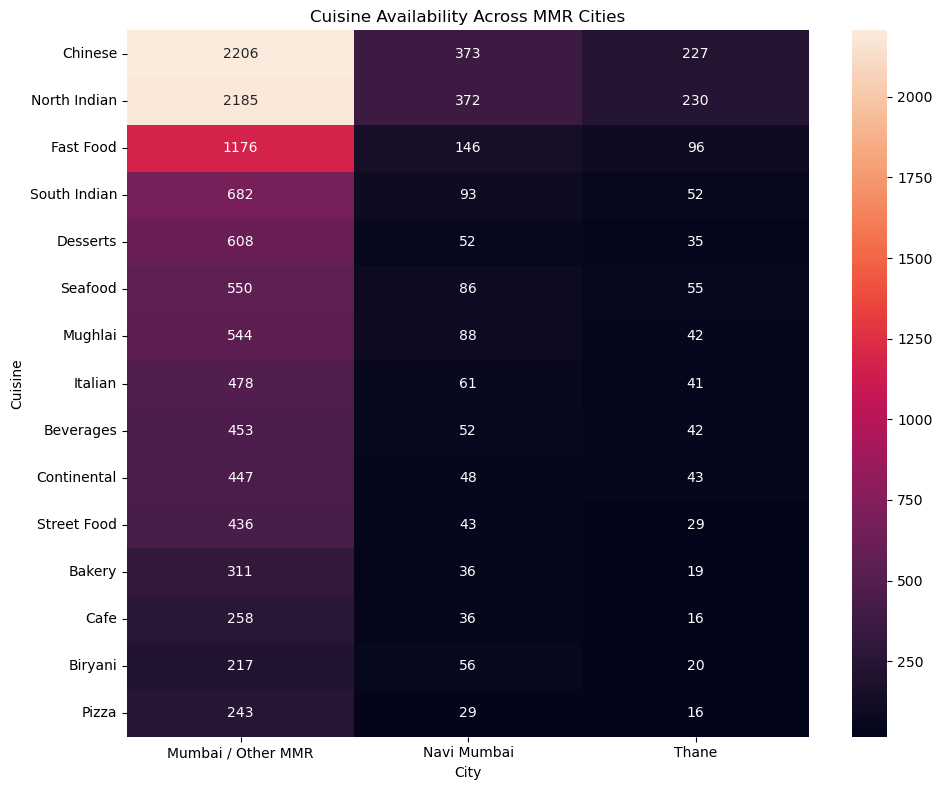

In [107]:
# Top 15 cuisines across MMR cities

top_cuisines = (
    cuisine_city_expanded["Cuisines"]
    .value_counts()
    .head(15)
    .index
)

heatmap_data = cuisine_supply.loc[top_cuisines]

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d"
)

plt.title("Cuisine Availability Across MMR Cities")
plt.xlabel("City")
plt.ylabel("Cuisine")
plt.tight_layout()

plt.show()

In [108]:
# Cuisine supply share within each city

cuisine_supply_pct = cuisine_supply.div(
    cuisine_supply.sum(axis=0),
    axis=1
) * 100

cuisine_supply_pct = cuisine_supply_pct.round(2)

cuisine_supply_pct.head(15)

City,Mumbai / Other MMR,Navi Mumbai,Thane
Cuisines,,,
Afghani,0.07,0.05,0.00
American,0.72,0.69,1.08
Andhra,0.04,0.00,0.00
Arabian,0.08,0.05,0.08
Asian,1.10,0.59,0.58
Asian Fusion,0.02,0.00,0.00
Awadhi,0.05,0.00,0.17
BBQ,0.20,0.05,0.25
Bakery,2.30,1.91,1.57


In [109]:
# Compare cuisine presence across cities

cuisine_gap = cuisine_supply_pct.copy()

cuisine_gap["Navi_Mumbai_Gap"] = (
    cuisine_gap["Mumbai / Other MMR"] -
    cuisine_gap["Navi Mumbai"]
)

cuisine_gap["Thane_Gap"] = (
    cuisine_gap["Mumbai / Other MMR"] -
    cuisine_gap["Thane"]
)

cuisine_gap.sort_values(
    "Navi_Mumbai_Gap",
    ascending=False
).head(15)

City,Mumbai / Other MMR,Navi Mumbai,Thane,Navi_Mumbai_Gap,Thane_Gap
Cuisines,,,,,
Desserts,4.49,2.77,2.89,1.72,1.60
Street Food,3.22,2.29,2.40,0.93,0.82
Fast Food,8.69,7.77,7.94,0.92,0.75
Continental,3.30,2.55,3.56,0.75,-0.26
Beverages,3.35,2.77,3.47,0.58,-0.12
Asian,1.10,0.59,0.58,0.51,0.52
Healthy Food,0.59,0.16,0.66,0.43,-0.07
European,0.58,0.16,0.50,0.42,0.08
Mediterranean,0.41,0.00,0.17,0.41,0.24


In [110]:
# Expected vs actual cuisine supply

city_totals = cuisine_supply.sum(axis=0)

expected_navi = (
    cuisine_supply["Mumbai / Other MMR"] /
    cuisine_supply["Mumbai / Other MMR"].sum()
) * city_totals["Navi Mumbai"]

expected_thane = (
    cuisine_supply["Mumbai / Other MMR"] /
    cuisine_supply["Mumbai / Other MMR"].sum()
) * city_totals["Thane"]

cuisine_gap_analysis = pd.DataFrame({
    "Mumbai_Supply": cuisine_supply["Mumbai / Other MMR"],
    "Navi_Mumbai_Actual": cuisine_supply["Navi Mumbai"],
    "Navi_Mumbai_Expected": expected_navi,
    "Thane_Actual": cuisine_supply["Thane"],
    "Thane_Expected": expected_thane
})

cuisine_gap_analysis["Navi_Mumbai_Gap"] = (
    cuisine_gap_analysis["Navi_Mumbai_Expected"] -
    cuisine_gap_analysis["Navi_Mumbai_Actual"]
)

cuisine_gap_analysis["Thane_Gap"] = (
    cuisine_gap_analysis["Thane_Expected"] -
    cuisine_gap_analysis["Thane_Actual"]
)

cuisine_gap_analysis.sort_values(
    "Navi_Mumbai_Gap",
    ascending=False
).head(15)

,Mumbai_Supply,Navi_Mumbai_Actual,Navi_Mumbai_Expected,Thane_Actual,Thane_Expected,Navi_Mumbai_Gap,Thane_Gap
Cuisines,,,,,,,
Desserts,608,52,84.463164,35,54.317003,32.463164,19.317003
Street Food,436,43,60.568980,29,38.951009,17.568980,9.951009
Fast Food,1176,146,163.369541,96,105.060519,17.369541,9.060519
Continental,447,48,62.097096,43,39.933718,14.097096,-3.066282
Beverages,453,52,62.930614,42,40.469741,10.930614,-1.530259
Asian,149,11,20.699032,7,13.311239,9.699032,6.311239
Healthy Food,80,3,11.113574,8,7.146974,8.113574,-0.853026
European,78,3,10.835735,6,6.968300,7.835735,0.968300
Mediterranean,56,0,7.779502,2,5.002882,7.779502,3.002882


In [111]:
# Positive cuisine gaps = potential underserved cuisines

navi_gap = cuisine_gap_analysis[
    cuisine_gap_analysis["Navi_Mumbai_Gap"] > 0
].copy()

thane_gap = cuisine_gap_analysis[
    cuisine_gap_analysis["Thane_Gap"] > 0
].copy()

print("Top underserved cuisines in Navi Mumbai:")
display(
    navi_gap.sort_values(
        "Navi_Mumbai_Gap",
        ascending=False
    )[[
        "Mumbai_Supply",
        "Navi_Mumbai_Actual",
        "Navi_Mumbai_Expected",
        "Navi_Mumbai_Gap"
    ]].head(15)
)

print("Top underserved cuisines in Thane:")
display(
    thane_gap.sort_values(
        "Thane_Gap",
        ascending=False
    )[[
        "Mumbai_Supply",
        "Thane_Actual",
        "Thane_Expected",
        "Thane_Gap"
    ]].head(15)
)

Top underserved cuisines in Navi Mumbai:


,Mumbai_Supply,Navi_Mumbai_Actual,Navi_Mumbai_Expected,Navi_Mumbai_Gap
Cuisines,,,,
Desserts,608,52,84.463164,32.463164
Street Food,436,43,60.568980,17.568980
Fast Food,1176,146,163.369541,17.369541
Continental,447,48,62.097096,14.097096
Beverages,453,52,62.930614,10.930614
Asian,149,11,20.699032,9.699032
Healthy Food,80,3,11.113574,8.113574
European,78,3,10.835735,7.835735
Mediterranean,56,0,7.779502,7.779502


Top underserved cuisines in Thane:


,Mumbai_Supply,Thane_Actual,Thane_Expected,Thane_Gap
Cuisines,,,,
Desserts,608,35,54.317003,19.317003
Street Food,436,29,38.951009,9.951009
Fast Food,1176,96,105.060519,9.060519
South Indian,682,52,60.927954,8.927954
Bakery,311,19,27.783862,8.783862
Cafe,258,16,23.048991,7.048991
Mughlai,544,42,48.599424,6.599424
Lebanese,82,1,7.325648,6.325648
Asian,149,7,13.311239,6.311239


In [112]:
opportunity.columns

Index(['City', 'Cuisines', 'Restaurant_Count', 'Average_Rating',
       'Average_Votes', 'Demand_Score', 'Scarcity_Score', 'Opportunity_Score'],
      dtype='object')

In [113]:
opportunity.head(10)

,City,Cuisines,Restaurant_Count,Average_Rating,Average_Votes,Demand_Score,Scarcity_Score,Opportunity_Score
1139,Mumbai / Other MMR,Modern Indian,7,4.385714,1497.428571,1.000000,0.990050,0.996020
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",9,3.388889,218.000000,1.000000,0.894737,0.957895
2274,Thane,Maharashtrian,8,3.950000,386.875000,1.000000,0.884615,0.953846
931,Mumbai / Other MMR,"Italian, Continental",5,4.100000,1118.600000,0.742088,1.000000,0.845253
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",9,3.522222,171.000000,0.757231,0.894737,0.812234
973,Mumbai / Other MMR,"Italian, Pizza",12,3.916667,1062.166667,0.703667,0.965174,0.808270
1888,Navi Mumbai,"Chinese, North Indian, Seafood",5,3.260000,151.600000,0.657025,1.000000,0.794215
2037,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",5,3.580000,134.600000,0.569215,1.000000,0.741529
532,Mumbai / Other MMR,Continental,10,4.070000,884.200000,0.582505,0.975124,0.739553
2297,Thane,North Indian,10,3.620000,272.400000,0.659491,0.807692,0.718771


In [114]:
opportunity[[
    "City",
    "Cuisines",
    "Demand_Score",
    "Scarcity_Score",
    "Opportunity_Score"
]].head(20)

,City,Cuisines,Demand_Score,Scarcity_Score,Opportunity_Score
1139,Mumbai / Other MMR,Modern Indian,1.000000,0.990050,0.996020
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",1.000000,0.894737,0.957895
2274,Thane,Maharashtrian,1.000000,0.884615,0.953846
931,Mumbai / Other MMR,"Italian, Continental",0.742088,1.000000,0.845253
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",0.757231,0.894737,0.812234
973,Mumbai / Other MMR,"Italian, Pizza",0.703667,0.965174,0.808270
1888,Navi Mumbai,"Chinese, North Indian, Seafood",0.657025,1.000000,0.794215
2037,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",0.569215,1.000000,0.741529
532,Mumbai / Other MMR,Continental,0.582505,0.975124,0.739553
2297,Thane,North Indian,0.659491,0.807692,0.718771


In [115]:
# Top cuisine opportunities in Navi Mumbai

navi_opportunities = opportunity[
    opportunity["City"] == "Navi Mumbai"
].copy()

navi_opportunities = navi_opportunities.sort_values(
    "Opportunity_Score",
    ascending=False
)

navi_opportunities[
    [
        "City",
        "Cuisines",
        "Restaurant_Count",
        "Demand_Score",
        "Scarcity_Score",
        "Opportunity_Score"
    ]
].head(15)

,City,Cuisines,Restaurant_Count,Demand_Score,Scarcity_Score,Opportunity_Score
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",9,1.000000,0.894737,0.957895
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",9,0.757231,0.894737,0.812234
1888,Navi Mumbai,"Chinese, North Indian, Seafood",5,0.657025,1.000000,0.794215
2037,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",5,0.569215,1.000000,0.741529
2006,Navi Mumbai,North Indian,15,0.686295,0.736842,0.706514
2021,Navi Mumbai,"North Indian, Chinese, Fast Food",5,0.422521,1.000000,0.653512
1792,Navi Mumbai,Bakery,6,0.433540,0.973684,0.649598
2015,Navi Mumbai,"North Indian, Chinese, Biryani",5,0.364669,1.000000,0.618802
1875,Navi Mumbai,"Chinese, North Indian",22,0.578559,0.552632,0.568188
1793,Navi Mumbai,"Bakery, Desserts",15,0.381887,0.736842,0.523869


In [116]:
# Top cuisine opportunities in Thane

thane_opportunities = opportunity[
    opportunity["City"] == "Thane"
].copy()

thane_opportunities = thane_opportunities.sort_values(
    "Opportunity_Score",
    ascending=False
)

thane_opportunities[
    [
        "City",
        "Cuisines",
        "Restaurant_Count",
        "Demand_Score",
        "Scarcity_Score",
        "Opportunity_Score"
    ]
].head(15)

,City,Cuisines,Restaurant_Count,Demand_Score,Scarcity_Score,Opportunity_Score
2274,Thane,Maharashtrian,8,1.000000,0.884615,0.953846
2297,Thane,North Indian,10,0.659491,0.807692,0.718771
2388,Thane,"South Indian, North Indian, Chinese",5,0.312660,1.000000,0.587596
2397,Thane,Street Food,6,0.297887,0.961538,0.563347
2320,Thane,"North Indian, Chinese, Seafood",7,0.241867,0.923077,0.514351
2149,Thane,"Bakery, Desserts",9,0.130817,0.846154,0.416952
2148,Thane,Bakery,6,0.043564,0.961538,0.410754
2184,Thane,"Chinese, North Indian",13,0.058132,0.692308,0.311802
2227,Thane,Fast Food,16,0.000000,0.576923,0.230769
2170,Thane,Chinese,27,0.190638,0.153846,0.175922


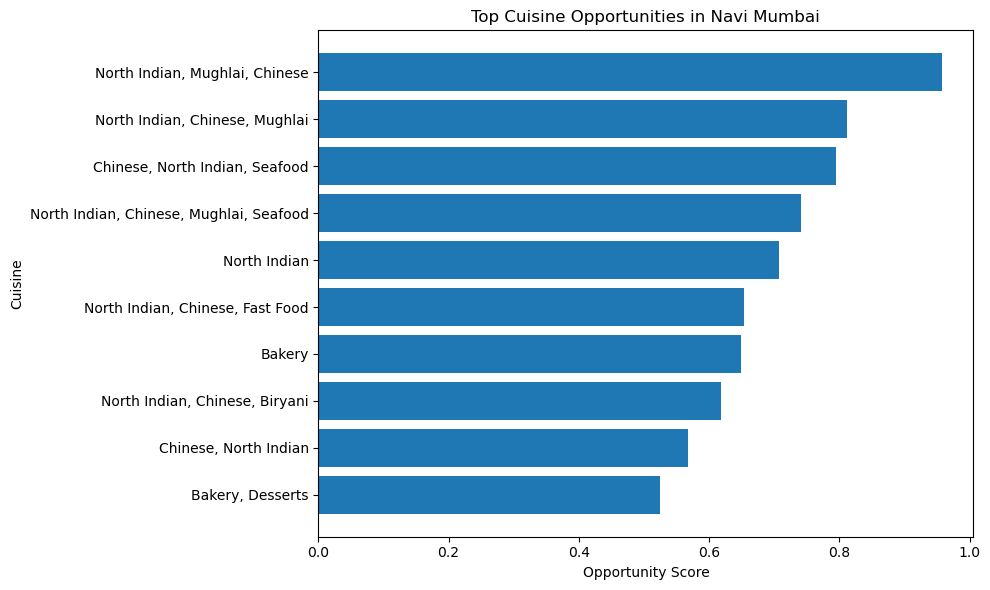

In [117]:
import matplotlib.pyplot as plt

# Top 10 opportunities in each city
navi_top10 = navi_opportunities.head(10).copy()
thane_top10 = thane_opportunities.head(10).copy()

# Plot Navi Mumbai
plt.figure(figsize=(10, 6))

plt.barh(
    navi_top10["Cuisines"][::-1],
    navi_top10["Opportunity_Score"][::-1]
)

plt.xlabel("Opportunity Score")
plt.ylabel("Cuisine")
plt.title("Top Cuisine Opportunities in Navi Mumbai")

plt.tight_layout()
plt.show()

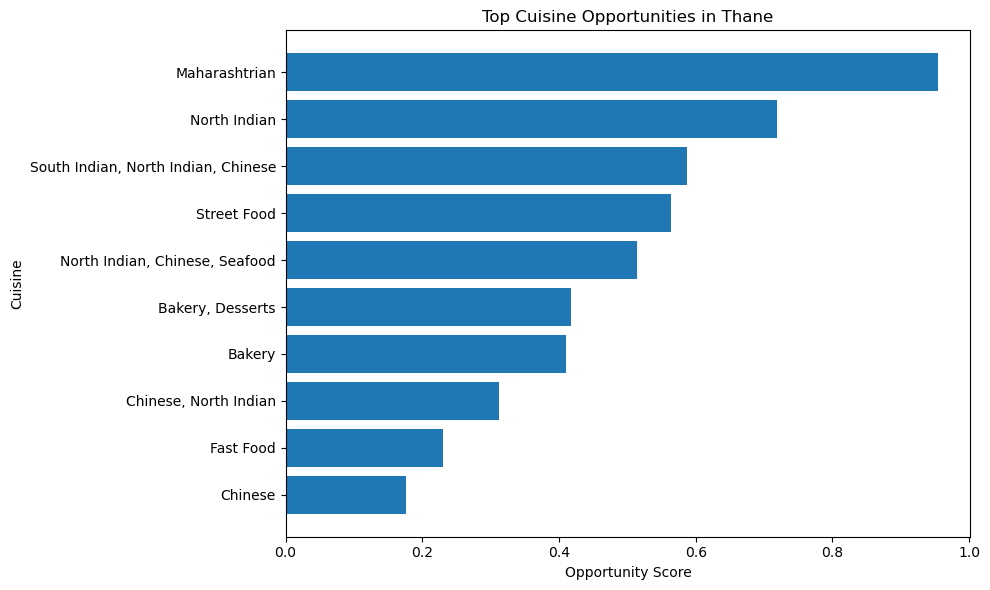

In [118]:
plt.figure(figsize=(10, 6))

plt.barh(
    thane_top10["Cuisines"][::-1],
    thane_top10["Opportunity_Score"][::-1]
)

plt.xlabel("Opportunity Score")
plt.ylabel("Cuisine")
plt.title("Top Cuisine Opportunities in Thane")

plt.tight_layout()
plt.show()

In [120]:
# Competition analysis by cuisine and city

competition = df_clean[
    ["City", "Cuisines", "Rating", "Votes"]
].copy()

# Expand cuisines so each cuisine gets its own row
competition["Cuisines"] = competition["Cuisines"].str.split(", ")

competition = competition.explode("Cuisines")

# Summarise competition by city and cuisine
competition_summary = (
    competition
    .groupby(["City", "Cuisines"])
    .agg(
        Restaurant_Count=("Cuisines", "size"),
        Average_Rating=("Rating", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

competition_summary.head(20)

,City,Cuisines,Restaurant_Count,Average_Rating,Average_Votes
0,Mumbai / Other MMR,Afghani,9,3.711111,130.222222
1,Mumbai / Other MMR,American,97,3.991753,974.649485
2,Mumbai / Other MMR,Andhra,5,4.260000,575.800000
3,Mumbai / Other MMR,Arabian,11,3.500000,171.545455
4,Mumbai / Other MMR,Asian,149,4.006711,771.738255
5,Mumbai / Other MMR,Asian Fusion,3,3.766667,182.333333
6,Mumbai / Other MMR,Awadhi,7,4.000000,510.714286
7,Mumbai / Other MMR,BBQ,27,3.862963,626.592593
8,Mumbai / Other MMR,Bakery,311,3.749518,213.437299
9,Mumbai / Other MMR,Bar Food,5,3.880000,1071.400000


In [121]:
# Top cuisines by restaurant count in each city

top_competitive = (
    competition_summary
    .sort_values(
        ["City", "Restaurant_Count"],
        ascending=[True, False]
    )
    .groupby("City")
    .head(15)
)

top_competitive[
    [
        "City",
        "Cuisines",
        "Restaurant_Count",
        "Average_Rating",
        "Average_Votes"
    ]
]

,City,Cuisines,Restaurant_Count,Average_Rating,Average_Votes
26,Mumbai / Other MMR,Chinese,2206,3.552992,248.625113
82,Mumbai / Other MMR,North Indian,2185,3.586087,285.356979
38,Mumbai / Other MMR,Fast Food,1176,3.596769,228.890306
100,Mumbai / Other MMR,South Indian,682,3.540469,239.354839
33,Mumbai / Other MMR,Desserts,608,3.830757,317.819079
96,Mumbai / Other MMR,Seafood,550,3.609091,276.872727
79,Mumbai / Other MMR,Mughlai,544,3.579412,317.496324
56,Mumbai / Other MMR,Italian,478,3.906276,673.809623
12,Mumbai / Other MMR,Beverages,453,3.675055,245.947020
29,Mumbai / Other MMR,Continental,447,3.912304,632.552573


In [122]:
# Classify cuisine competition levels

competition_summary["Competition_Level"] = pd.cut(
    competition_summary["Restaurant_Count"],
    bins=[-1, 10, 50, 200, float("inf")],
    labels=["Low", "Moderate", "High", "Very High"]
)

competition_summary[
    [
        "City",
        "Cuisines",
        "Restaurant_Count",
        "Average_Rating",
        "Average_Votes",
        "Competition_Level"
    ]
].head(30)

,City,Cuisines,Restaurant_Count,Average_Rating,Average_Votes,Competition_Level
0,Mumbai / Other MMR,Afghani,9,3.711111,130.222222,Low
1,Mumbai / Other MMR,American,97,3.991753,974.649485,High
2,Mumbai / Other MMR,Andhra,5,4.260000,575.800000,Low
3,Mumbai / Other MMR,Arabian,11,3.500000,171.545455,Moderate
4,Mumbai / Other MMR,Asian,149,4.006711,771.738255,High
5,Mumbai / Other MMR,Asian Fusion,3,3.766667,182.333333,Low
6,Mumbai / Other MMR,Awadhi,7,4.000000,510.714286,Low
7,Mumbai / Other MMR,BBQ,27,3.862963,626.592593,Moderate
8,Mumbai / Other MMR,Bakery,311,3.749518,213.437299,Very High
9,Mumbai / Other MMR,Bar Food,5,3.880000,1071.400000,Low


In [123]:
# Low-competition cuisines by city

low_competition = (
    competition_summary[
        competition_summary["Competition_Level"].isin(["Low", "Moderate"])
    ]
    .sort_values(
        ["City", "Restaurant_Count"],
        ascending=[True, True]
    )
)

low_competition[
    [
        "City",
        "Cuisines",
        "Restaurant_Count",
        "Average_Rating",
        "Average_Votes",
        "Competition_Level"
    ]
].head(50)


,City,Cuisines,Restaurant_Count,Average_Rating,Average_Votes,Competition_Level
10,Mumbai / Other MMR,Belgian,1,3.600000,19.000000,Low
16,Mumbai / Other MMR,Brazilian,1,4.400000,583.000000,Low
30,Mumbai / Other MMR,Crepes,1,3.400000,58.000000,Low
32,Mumbai / Other MMR,Deli,1,4.100000,129.000000,Low
35,Mumbai / Other MMR,Egyptian,1,4.900000,1037.000000,Low
37,Mumbai / Other MMR,Falafel,1,4.100000,26.000000,Low
41,Mumbai / Other MMR,Fried Chicken,1,3.800000,193.000000,Low
49,Mumbai / Other MMR,Hot Pot,1,4.000000,1075.000000,Low
54,Mumbai / Other MMR,International,1,4.000000,843.000000,Low
63,Mumbai / Other MMR,Korean BBQ,1,3.900000,118.000000,Low


In [124]:
# Overall market comparison by city

market_summary = (
    competition_summary
    .groupby("City")
    .agg(
        Total_Cuisine_Categories=("Cuisines", "nunique"),
        Total_Restaurants=("Restaurant_Count", "sum"),
        Average_Rating=("Average_Rating", "mean"),
        Average_Votes=("Average_Votes", "mean")
    )
    .reset_index()
)

market_summary

,City,Total_Cuisine_Categories,Total_Restaurants,Average_Rating,Average_Votes
0,Mumbai / Other MMR,115,13533,3.910062,552.332136
1,Navi Mumbai,64,1880,3.710988,270.232579
2,Thane,64,1209,3.835695,317.014285


In [125]:
# Compare cities by restaurant supply

market_summary.sort_values(
    "Total_Restaurants",
    ascending=False
)

,City,Total_Cuisine_Categories,Total_Restaurants,Average_Rating,Average_Votes
0,Mumbai / Other MMR,115,13533,3.910062,552.332136
1,Navi Mumbai,64,1880,3.710988,270.232579
2,Thane,64,1209,3.835695,317.014285


In [126]:
# Overall opportunity comparison by city

city_opportunity_summary = (
    opportunity
    .groupby("City")
    .agg(
        Avg_Demand_Score=("Demand_Score", "mean"),
        Avg_Scarcity_Score=("Scarcity_Score", "mean"),
        Avg_Opportunity_Score=("Opportunity_Score", "mean"),
        Max_Opportunity_Score=("Opportunity_Score", "max"),
        High_Opportunity_Count=("Opportunity_Score", lambda x: (x >= 0.60).sum())
    )
    .reset_index()
)

city_opportunity_summary.sort_values(
    "Avg_Opportunity_Score",
    ascending=False
)

,City,Avg_Demand_Score,Avg_Scarcity_Score,Avg_Opportunity_Score,Max_Opportunity_Score,High_Opportunity_Count
1,Navi Mumbai,0.376322,0.831579,0.558425,0.957895,8
0,Mumbai / Other MMR,0.136737,0.930842,0.454379,0.996020,12
2,Thane,0.273712,0.709790,0.448143,0.953846,2


In [127]:
# Top cuisine opportunities across the entire MMR

top_market_opportunities = (
    opportunity
    .sort_values("Opportunity_Score", ascending=False)
    [[
        "City",
        "Cuisines",
        "Restaurant_Count",
        "Demand_Score",
        "Scarcity_Score",
        "Opportunity_Score"
    ]]
    .head(30)
)

top_market_opportunities

,City,Cuisines,Restaurant_Count,Demand_Score,Scarcity_Score,Opportunity_Score
1139,Mumbai / Other MMR,Modern Indian,7,1.000000,0.990050,0.996020
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",9,1.000000,0.894737,0.957895
2274,Thane,Maharashtrian,8,1.000000,0.884615,0.953846
931,Mumbai / Other MMR,"Italian, Continental",5,0.742088,1.000000,0.845253
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",9,0.757231,0.894737,0.812234
973,Mumbai / Other MMR,"Italian, Pizza",12,0.703667,0.965174,0.808270
1888,Navi Mumbai,"Chinese, North Indian, Seafood",5,0.657025,1.000000,0.794215
2037,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",5,0.569215,1.000000,0.741529
532,Mumbai / Other MMR,Continental,10,0.582505,0.975124,0.739553
2297,Thane,North Indian,10,0.659491,0.807692,0.718771


In [128]:
# Top cuisine opportunities in Navi Mumbai

navi_top_opportunities = (
    opportunity[opportunity["City"] == "Navi Mumbai"]
    .sort_values("Opportunity_Score", ascending=False)
    [[
        "City",
        "Cuisines",
        "Restaurant_Count",
        "Demand_Score",
        "Scarcity_Score",
        "Opportunity_Score"
    ]]
    .head(15)
)

navi_top_opportunities

,City,Cuisines,Restaurant_Count,Demand_Score,Scarcity_Score,Opportunity_Score
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",9,1.000000,0.894737,0.957895
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",9,0.757231,0.894737,0.812234
1888,Navi Mumbai,"Chinese, North Indian, Seafood",5,0.657025,1.000000,0.794215
2037,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",5,0.569215,1.000000,0.741529
2006,Navi Mumbai,North Indian,15,0.686295,0.736842,0.706514
2021,Navi Mumbai,"North Indian, Chinese, Fast Food",5,0.422521,1.000000,0.653512
1792,Navi Mumbai,Bakery,6,0.433540,0.973684,0.649598
2015,Navi Mumbai,"North Indian, Chinese, Biryani",5,0.364669,1.000000,0.618802
1875,Navi Mumbai,"Chinese, North Indian",22,0.578559,0.552632,0.568188
1793,Navi Mumbai,"Bakery, Desserts",15,0.381887,0.736842,0.523869


In [129]:
# Top market opportunities in Thane

thane_top_opportunities = (
    opportunity[opportunity["City"] == "Thane"]
    .sort_values("Opportunity_Score", ascending=False)
    [
        [
            "City",
            "Cuisines",
            "Restaurant_Count",
            "Demand_Score",
            "Scarcity_Score",
            "Opportunity_Score"
        ]
    ]
    .head(15)
)

thane_top_opportunities

,City,Cuisines,Restaurant_Count,Demand_Score,Scarcity_Score,Opportunity_Score
2274,Thane,Maharashtrian,8,1.000000,0.884615,0.953846
2297,Thane,North Indian,10,0.659491,0.807692,0.718771
2388,Thane,"South Indian, North Indian, Chinese",5,0.312660,1.000000,0.587596
2397,Thane,Street Food,6,0.297887,0.961538,0.563347
2320,Thane,"North Indian, Chinese, Seafood",7,0.241867,0.923077,0.514351
2149,Thane,"Bakery, Desserts",9,0.130817,0.846154,0.416952
2148,Thane,Bakery,6,0.043564,0.961538,0.410754
2184,Thane,"Chinese, North Indian",13,0.058132,0.692308,0.311802
2227,Thane,Fast Food,16,0.000000,0.576923,0.230769
2170,Thane,Chinese,27,0.190638,0.153846,0.175922


In [130]:
# Top 10 opportunities across Mumbai, Navi Mumbai and Thane

top_opportunities_all = (
    opportunity
    .sort_values("Opportunity_Score", ascending=False)
    [
        [
            "City",
            "Cuisines",
            "Restaurant_Count",
            "Demand_Score",
            "Scarcity_Score",
            "Opportunity_Score"
        ]
    ]
    .head(10)
)

top_opportunities_all

,City,Cuisines,Restaurant_Count,Demand_Score,Scarcity_Score,Opportunity_Score
1139,Mumbai / Other MMR,Modern Indian,7,1.000000,0.990050,0.996020
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",9,1.000000,0.894737,0.957895
2274,Thane,Maharashtrian,8,1.000000,0.884615,0.953846
931,Mumbai / Other MMR,"Italian, Continental",5,0.742088,1.000000,0.845253
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",9,0.757231,0.894737,0.812234
973,Mumbai / Other MMR,"Italian, Pizza",12,0.703667,0.965174,0.808270
1888,Navi Mumbai,"Chinese, North Indian, Seafood",5,0.657025,1.000000,0.794215
2037,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",5,0.569215,1.000000,0.741529
532,Mumbai / Other MMR,Continental,10,0.582505,0.975124,0.739553
2297,Thane,North Indian,10,0.659491,0.807692,0.718771


In [131]:
# Compare average opportunity score across cities

city_opportunity_comparison = (
    opportunity
    .groupby("City")
    .agg(
        Average_Opportunity_Score=("Opportunity_Score", "mean"),
        Highest_Opportunity_Score=("Opportunity_Score", "max"),
        High_Opportunity_Count=("Opportunity_Score", lambda x: (x >= 0.60).sum())
    )
    .reset_index()
    .sort_values("Average_Opportunity_Score", ascending=False)
)

city_opportunity_comparison

,City,Average_Opportunity_Score,Highest_Opportunity_Score,High_Opportunity_Count
1,Navi Mumbai,0.558425,0.957895,8
0,Mumbai / Other MMR,0.454379,0.996020,12
2,Thane,0.448143,0.953846,2


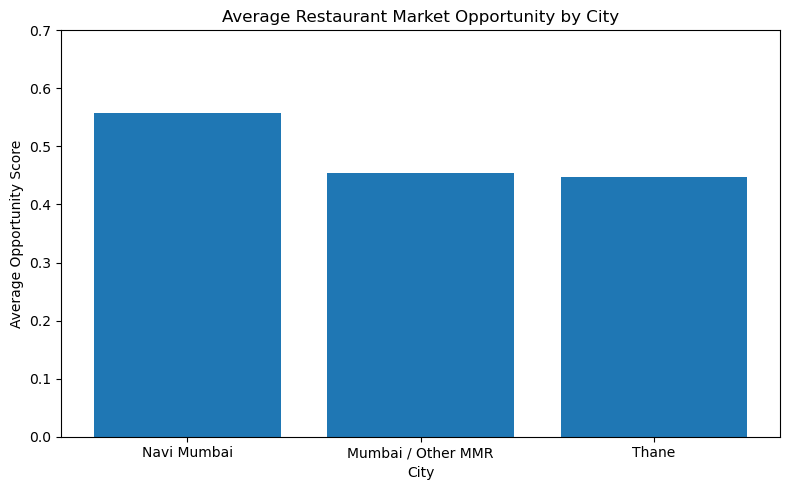

In [132]:
# Visualization: Average opportunity score by city

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    city_opportunity_comparison["City"],
    city_opportunity_comparison["Average_Opportunity_Score"]
)

plt.title("Average Restaurant Market Opportunity by City")
plt.xlabel("City")
plt.ylabel("Average Opportunity Score")
plt.ylim(0, 0.7)

plt.tight_layout()
plt.show()

In [133]:
# Cuisine-level market opportunity across cities

cuisine_opportunity = (
    opportunity
    .groupby(["City", "Cuisines"])
    .agg(
        Restaurant_Count=("Restaurant_Count", "sum"),
        Avg_Demand_Score=("Demand_Score", "mean"),
        Avg_Scarcity_Score=("Scarcity_Score", "mean"),
        Avg_Opportunity_Score=("Opportunity_Score", "mean"),
        Max_Opportunity_Score=("Opportunity_Score", "max")
    )
    .reset_index()
)

cuisine_opportunity = cuisine_opportunity.sort_values(
    "Avg_Opportunity_Score",
    ascending=False
)

cuisine_opportunity.head(20)

,City,Cuisines,Restaurant_Count,Avg_Demand_Score,Avg_Scarcity_Score,Avg_Opportunity_Score,Max_Opportunity_Score
89,Mumbai / Other MMR,Modern Indian,7,1.000000,0.990050,0.996020,0.996020
169,Navi Mumbai,"North Indian, Mughlai, Chinese",9,1.000000,0.894737,0.957895,0.957895
176,Thane,Maharashtrian,8,1.000000,0.884615,0.953846,0.953846
74,Mumbai / Other MMR,"Italian, Continental",5,0.742088,1.000000,0.845253,0.845253
166,Navi Mumbai,"North Indian, Chinese, Mughlai",9,0.757231,0.894737,0.812234,0.812234
76,Mumbai / Other MMR,"Italian, Pizza",12,0.703667,0.965174,0.808270,0.808270
156,Navi Mumbai,"Chinese, North Indian, Seafood",5,0.657025,1.000000,0.794215,0.794215
167,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",5,0.569215,1.000000,0.741529,0.741529
45,Mumbai / Other MMR,Continental,10,0.582505,0.975124,0.739553,0.739553
177,Thane,North Indian,10,0.659491,0.807692,0.718771,0.718771


In [134]:
# Top cuisine opportunities in Navi Mumbai

navi_cuisine_opportunities = (
    cuisine_opportunity[
        cuisine_opportunity["City"] == "Navi Mumbai"
    ]
    .sort_values("Avg_Opportunity_Score", ascending=False)
    .head(15)
)

navi_cuisine_opportunities

,City,Cuisines,Restaurant_Count,Avg_Demand_Score,Avg_Scarcity_Score,Avg_Opportunity_Score,Max_Opportunity_Score
169,Navi Mumbai,"North Indian, Mughlai, Chinese",9,1.000000,0.894737,0.957895,0.957895
166,Navi Mumbai,"North Indian, Chinese, Mughlai",9,0.757231,0.894737,0.812234,0.812234
156,Navi Mumbai,"Chinese, North Indian, Seafood",5,0.657025,1.000000,0.794215,0.794215
167,Navi Mumbai,"North Indian, Chinese, Mughlai, Seafood",5,0.569215,1.000000,0.741529,0.741529
162,Navi Mumbai,North Indian,15,0.686295,0.736842,0.706514,0.706514
165,Navi Mumbai,"North Indian, Chinese, Fast Food",5,0.422521,1.000000,0.653512,0.653512
151,Navi Mumbai,Bakery,6,0.433540,0.973684,0.649598,0.649598
164,Navi Mumbai,"North Indian, Chinese, Biryani",5,0.364669,1.000000,0.618802,0.618802
155,Navi Mumbai,"Chinese, North Indian",22,0.578559,0.552632,0.568188,0.568188
152,Navi Mumbai,"Bakery, Desserts",15,0.381887,0.736842,0.523869,0.523869


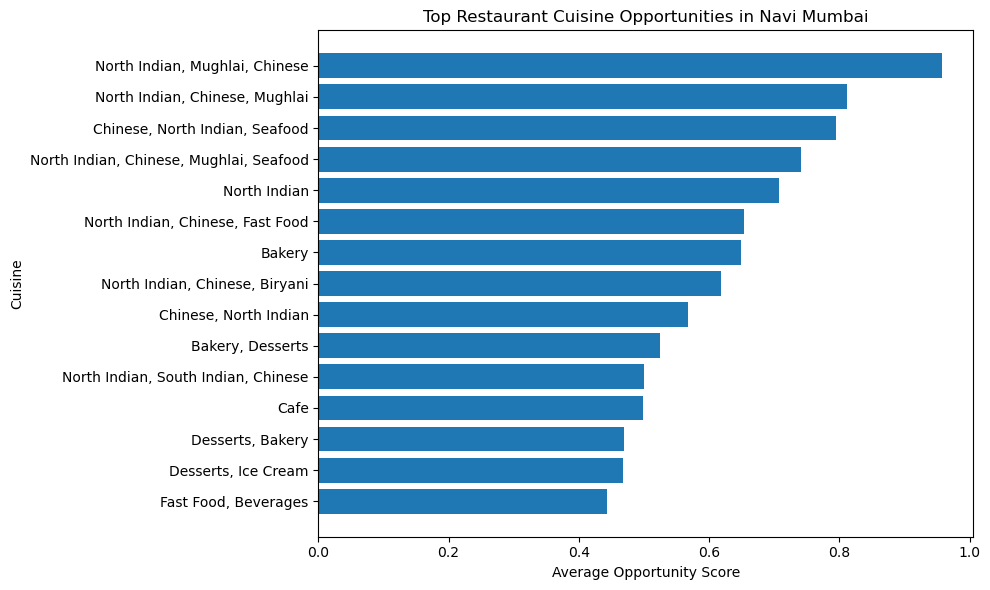

In [135]:
plt.figure(figsize=(10, 6))

plt.barh(
    navi_cuisine_opportunities["Cuisines"][::-1],
    navi_cuisine_opportunities["Avg_Opportunity_Score"][::-1]
)

plt.title("Top Restaurant Cuisine Opportunities in Navi Mumbai")
plt.xlabel("Average Opportunity Score")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

In [136]:
# Navi Mumbai: demand vs scarcity opportunity matrix

navi_matrix = (
    opportunity[opportunity["City"] == "Navi Mumbai"]
    .groupby("Cuisines")
    .agg(
        Restaurant_Count=("Restaurant_Count", "sum"),
        Avg_Demand=("Demand_Score", "mean"),
        Avg_Scarcity=("Scarcity_Score", "mean"),
        Avg_Opportunity=("Opportunity_Score", "mean")
    )
    .reset_index()
    .sort_values("Avg_Opportunity", ascending=False)
)

navi_matrix.head(20)

,Cuisines,Restaurant_Count,Avg_Demand,Avg_Scarcity,Avg_Opportunity
18,"North Indian, Mughlai, Chinese",9,1.000000,0.894737,0.957895
15,"North Indian, Chinese, Mughlai",9,0.757231,0.894737,0.812234
5,"Chinese, North Indian, Seafood",5,0.657025,1.000000,0.794215
16,"North Indian, Chinese, Mughlai, Seafood",5,0.569215,1.000000,0.741529
11,North Indian,15,0.686295,0.736842,0.706514
14,"North Indian, Chinese, Fast Food",5,0.422521,1.000000,0.653512
0,Bakery,6,0.433540,0.973684,0.649598
13,"North Indian, Chinese, Biryani",5,0.364669,1.000000,0.618802
4,"Chinese, North Indian",22,0.578559,0.552632,0.568188
1,"Bakery, Desserts",15,0.381887,0.736842,0.523869


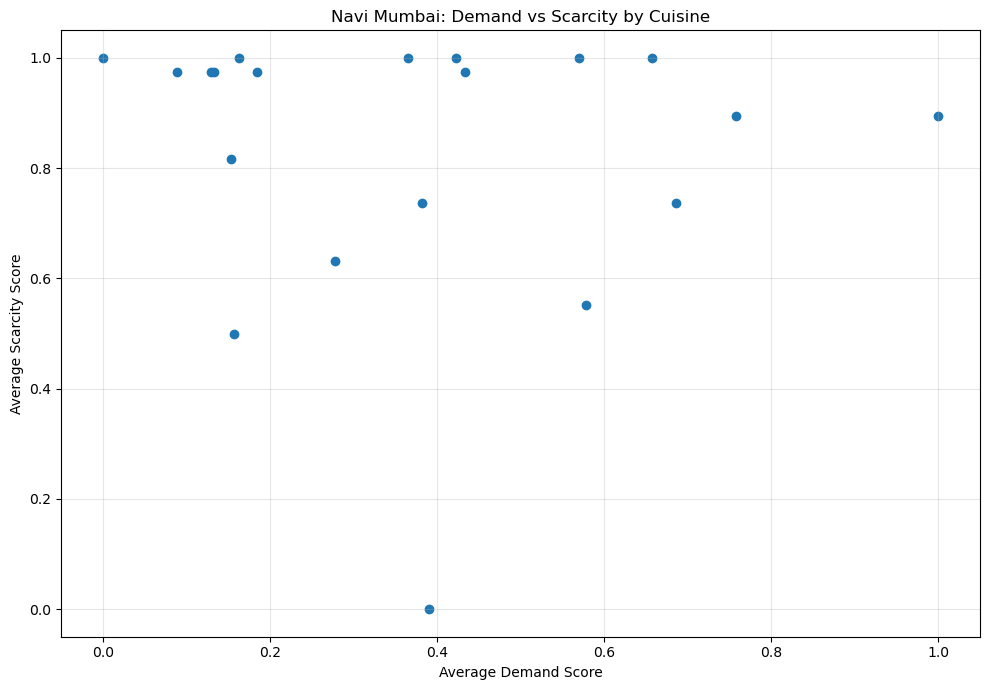

In [137]:
plt.figure(figsize=(10, 7))

plt.scatter(
    navi_matrix["Avg_Demand"],
    navi_matrix["Avg_Scarcity"]
)

plt.xlabel("Average Demand Score")
plt.ylabel("Average Scarcity Score")
plt.title("Navi Mumbai: Demand vs Scarcity by Cuisine")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

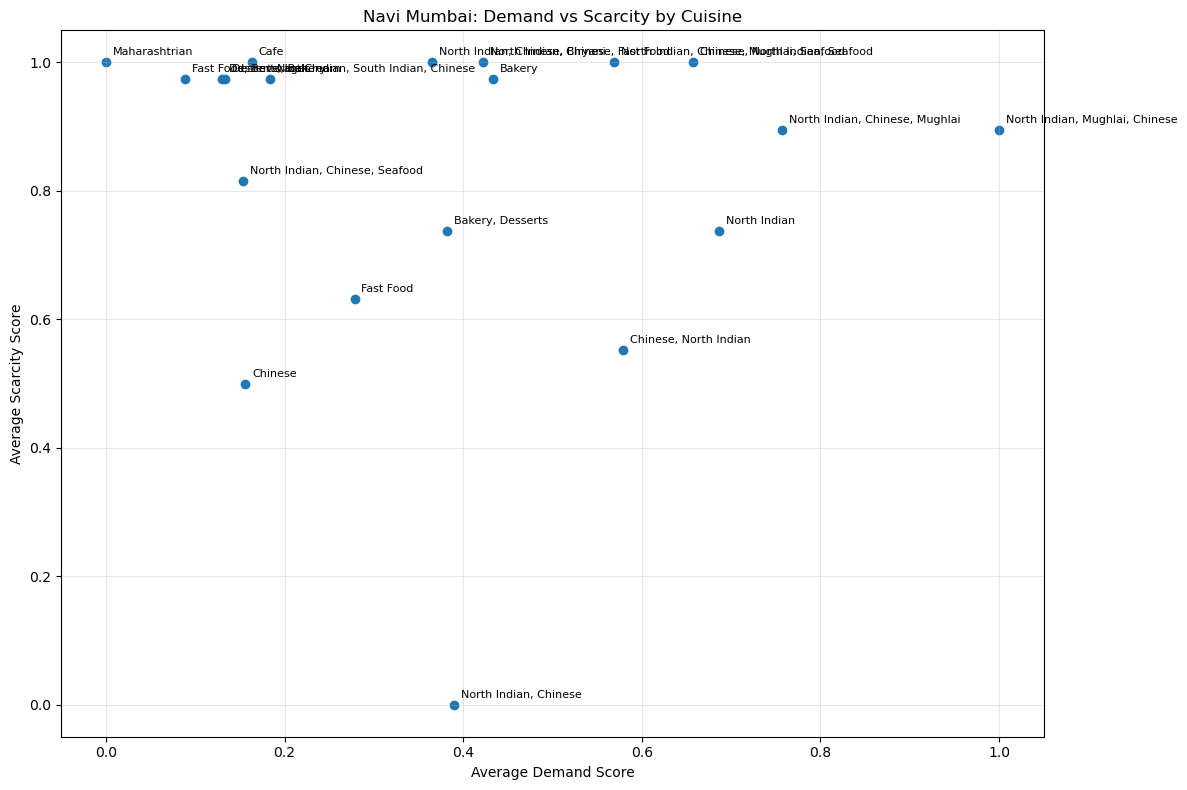

In [138]:
# Label the Navi Mumbai demand vs scarcity matrix

plt.figure(figsize=(12, 8))

plt.scatter(
    navi_matrix["Avg_Demand"],
    navi_matrix["Avg_Scarcity"]
)

for _, row in navi_matrix.iterrows():
    plt.annotate(
        row["Cuisines"],
        (row["Avg_Demand"], row["Avg_Scarcity"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Average Demand Score")
plt.ylabel("Average Scarcity Score")
plt.title("Navi Mumbai: Demand vs Scarcity by Cuisine")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [139]:
# Strongest Navi Mumbai opportunities
# based on both demand and scarcity

navi_matrix[
    (navi_matrix["Avg_Demand"] >= 0.50) &
    (navi_matrix["Avg_Scarcity"] >= 0.70)
].sort_values(
    "Avg_Opportunity",
    ascending=False
)

,Cuisines,Restaurant_Count,Avg_Demand,Avg_Scarcity,Avg_Opportunity
18,"North Indian, Mughlai, Chinese",9,1.000000,0.894737,0.957895
15,"North Indian, Chinese, Mughlai",9,0.757231,0.894737,0.812234
5,"Chinese, North Indian, Seafood",5,0.657025,1.000000,0.794215
16,"North Indian, Chinese, Mughlai, Seafood",5,0.569215,1.000000,0.741529
11,North Indian,15,0.686295,0.736842,0.706514


In [140]:
# Split cuisine combinations into individual cuisines

cuisine_exploded = opportunity.copy()

cuisine_exploded["Cuisine_List"] = (
    cuisine_exploded["Cuisines"]
    .str.split(",")
)

cuisine_exploded = cuisine_exploded.explode("Cuisine_List")

cuisine_exploded["Cuisine"] = (
    cuisine_exploded["Cuisine_List"]
    .str.strip()
)

cuisine_exploded[
    ["City", "Cuisines", "Cuisine", "Restaurant_Count",
     "Demand_Score", "Scarcity_Score", "Opportunity_Score"]
].head(20)

,City,Cuisines,Cuisine,Restaurant_Count,Demand_Score,Scarcity_Score,Opportunity_Score
1139,Mumbai / Other MMR,Modern Indian,Modern Indian,7,1.000000,0.990050,0.996020
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",North Indian,9,1.000000,0.894737,0.957895
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",Mughlai,9,1.000000,0.894737,0.957895
2064,Navi Mumbai,"North Indian, Mughlai, Chinese",Chinese,9,1.000000,0.894737,0.957895
2274,Thane,Maharashtrian,Maharashtrian,8,1.000000,0.884615,0.953846
931,Mumbai / Other MMR,"Italian, Continental",Italian,5,0.742088,1.000000,0.845253
931,Mumbai / Other MMR,"Italian, Continental",Continental,5,0.742088,1.000000,0.845253
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",North Indian,9,0.757231,0.894737,0.812234
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",Chinese,9,0.757231,0.894737,0.812234
2030,Navi Mumbai,"North Indian, Chinese, Mughlai",Mughlai,9,0.757231,0.894737,0.812234


In [141]:
# Individual cuisine opportunity in Navi Mumbai

navi_individual_cuisines = (
    cuisine_exploded[
        cuisine_exploded["City"] == "Navi Mumbai"
    ]
    .groupby("Cuisine")
    .agg(
        Combination_Count=("Cuisines", "nunique"),
        Restaurant_Count=("Restaurant_Count", "sum"),
        Avg_Demand=("Demand_Score", "mean"),
        Avg_Scarcity=("Scarcity_Score", "mean"),
        Avg_Opportunity=("Opportunity_Score", "mean")
    )
    .reset_index()
    .sort_values("Avg_Opportunity", ascending=False)
)

navi_individual_cuisines.head(20)

,Cuisine,Combination_Count,Restaurant_Count,Avg_Demand,Avg_Scarcity,Avg_Opportunity
9,Mughlai,3,23,0.775482,0.929825,0.837219
11,Seafood,3,22,0.459854,0.938596,0.651351
10,North Indian,11,136,0.523853,0.806220,0.636800
2,Biryani,1,5,0.364669,1.000000,0.618802
4,Chinese,11,145,0.475655,0.784689,0.599269
0,Bakery,3,27,0.316173,0.894737,0.547599
6,Fast Food,3,30,0.263022,0.868421,0.505182
12,South Indian,1,6,0.183884,0.973684,0.499804
3,Cafe,1,5,0.163223,1.000000,0.497934
5,Desserts,3,27,0.214876,0.894737,0.486820


In [142]:
# More reliable cuisine opportunities
# Exclude cuisines appearing in only one combination

navi_reliable_cuisines = (
    navi_individual_cuisines[
        navi_individual_cuisines["Combination_Count"] >= 2
    ]
    .sort_values("Avg_Opportunity", ascending=False)
)

navi_reliable_cuisines.head(15)

,Cuisine,Combination_Count,Restaurant_Count,Avg_Demand,Avg_Scarcity,Avg_Opportunity
9,Mughlai,3,23,0.775482,0.929825,0.837219
11,Seafood,3,22,0.459854,0.938596,0.651351
10,North Indian,11,136,0.523853,0.806220,0.636800
4,Chinese,11,145,0.475655,0.784689,0.599269
0,Bakery,3,27,0.316173,0.894737,0.547599
6,Fast Food,3,30,0.263022,0.868421,0.505182
5,Desserts,3,27,0.214876,0.894737,0.486820


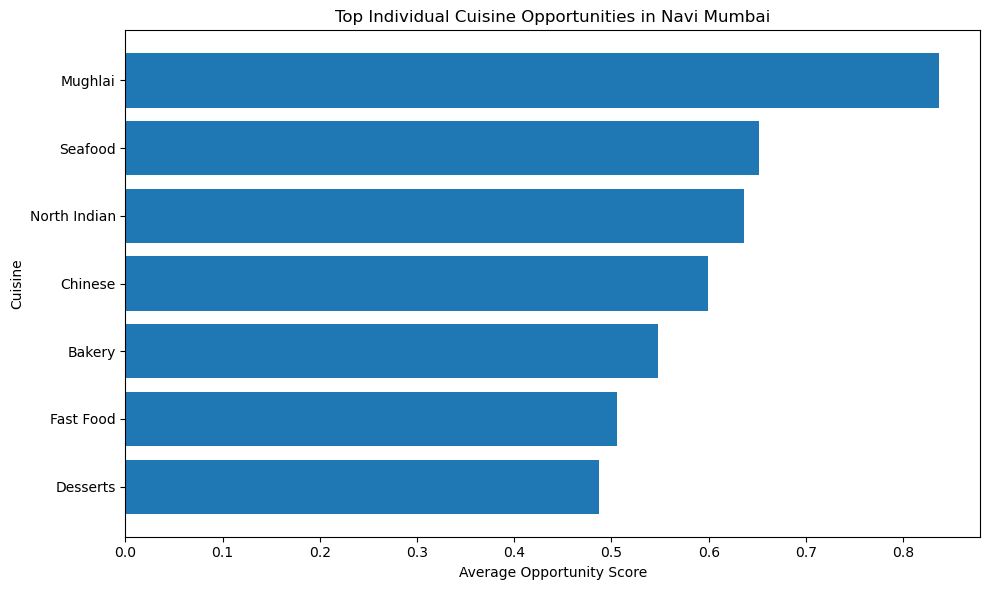

In [143]:
# Top individual cuisine opportunities in Navi Mumbai

top_cuisines = navi_reliable_cuisines.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cuisines["Cuisine"][::-1],
    top_cuisines["Avg_Opportunity"][::-1]
)

plt.xlabel("Average Opportunity Score")
plt.ylabel("Cuisine")
plt.title("Top Individual Cuisine Opportunities in Navi Mumbai")

plt.tight_layout()
plt.show()